In [3]:
!pip install scikit-posthocs matplotlib numpy pandas scipy Orange3

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/3.6 MB 5.6 MB/s eta 0:00:01
   -------------- ------------------------- 1.3/3.6 MB 4.8 MB/s eta 0:00:01
   ------------------------- -------------- 2.4/3.6 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 3.6/3.6 MB 4.8 MB/s eta 0:00:00


In [10]:
from visualization_helper_functions_matplotlib import Helper

# Evaluation of the models according to research methodology

In [17]:
outputs_folder = "outputs"
outputs_csv_folder = "tensorboard_csvs"
outputs_result_comparison_folder = "results_comparison"

In [19]:
experiments = ['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE',
               'defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE',
               'defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE',
               'defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE',
               'defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE',
               'defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE',
               'defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC',
               
               'solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE',
               'solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']
experiment_results = dict()
for experiment in experiments:
    experiment_results[experiment] = Helper.extract_results(outputs_result_comparison_folder, experiment)

## Codegen 350M, 6B, 16B repliation on Defects4j


Friedman Test: statistic = 7.4000, p = 0.0247

Average Ranks:
codegen_350M: 2.700
codegen_6B: 1.700
codegen_16B: 1.600

Nemenyi Post-hoc Test (p-values):
              codegen_350M  codegen_6B  codegen_16B
codegen_350M      1.000000    0.065260     0.037023
codegen_6B        0.065260    1.000000     0.972813
codegen_16B       0.037023    0.972813     1.000000

Significant Differences (p < 0.05):
codegen_16B is significantly better than codegen_350M (p = 0.0370)


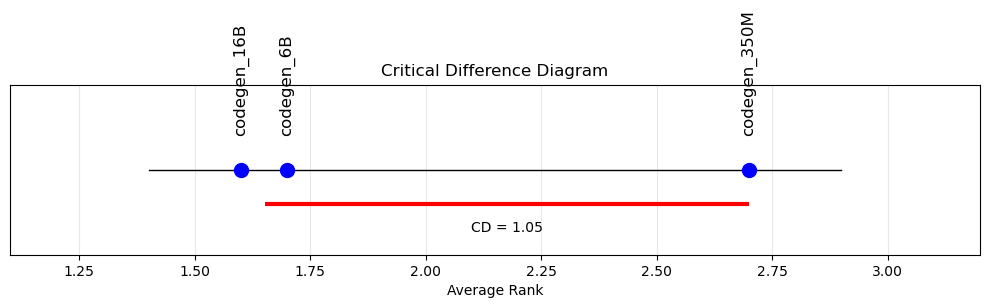

In [22]:
Helper.friedman_and_nemenyi({'codegen_350M': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['f1_score'],
                             'codegen_6B': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['f1_score'],
                             'codegen_16B': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['f1_score']},
                            fig_width=1000, fig_height=300)

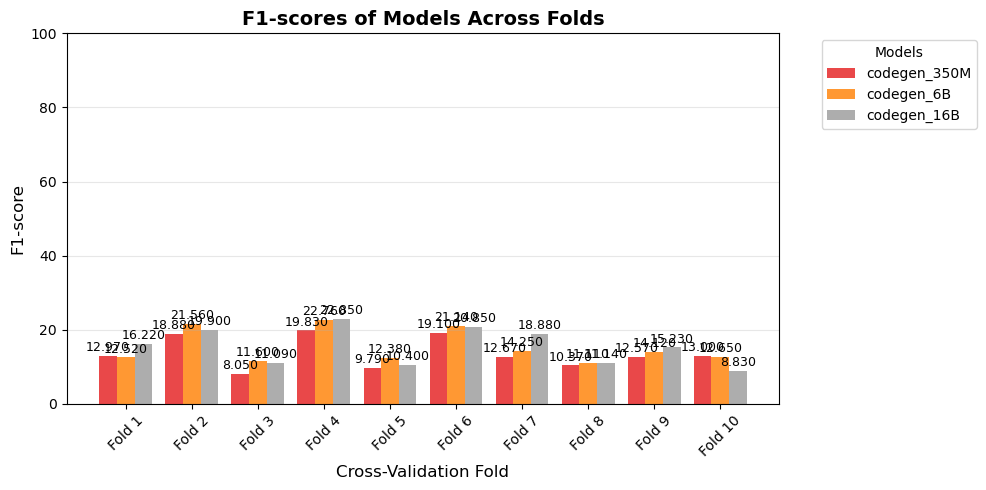

In [24]:
Helper.plot_grouped_bar_chart({'codegen_350M': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['f1_score'],
                             'codegen_6B': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['f1_score'],
                             'codegen_16B': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['f1_score']},
                             title="F1-scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1000)

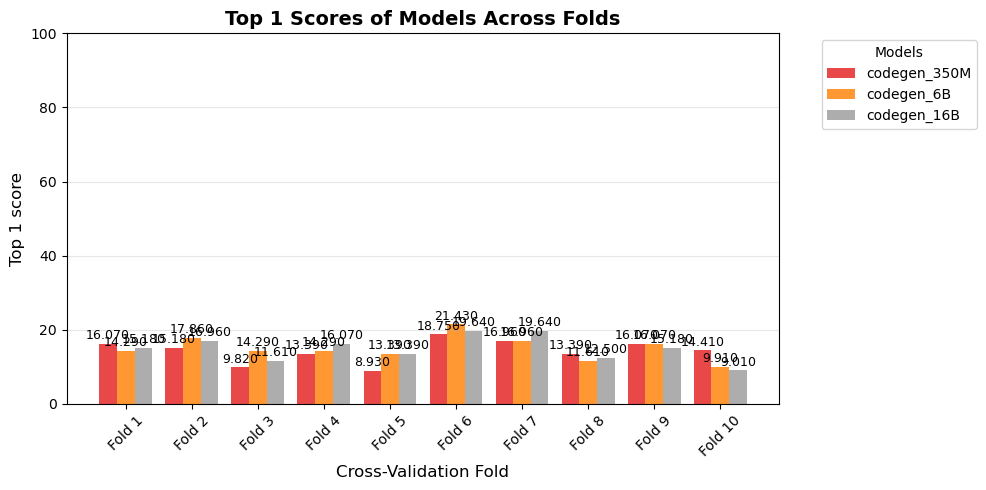

In [26]:
Helper.plot_grouped_bar_chart({'codegen_350M': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['top_1'],
                             'codegen_6B': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['top_1'],
                             'codegen_16B': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_1']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1000)

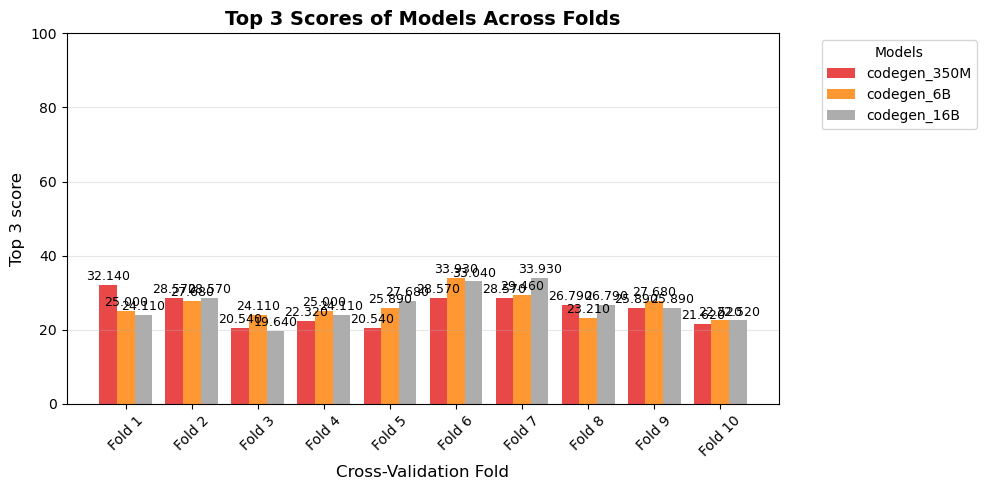

In [28]:
Helper.plot_grouped_bar_chart({'codegen_350M': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['top_3'],
                             'codegen_6B': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['top_3'],
                             'codegen_16B': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_3']},
                             title="Top 3 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 3 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1000)

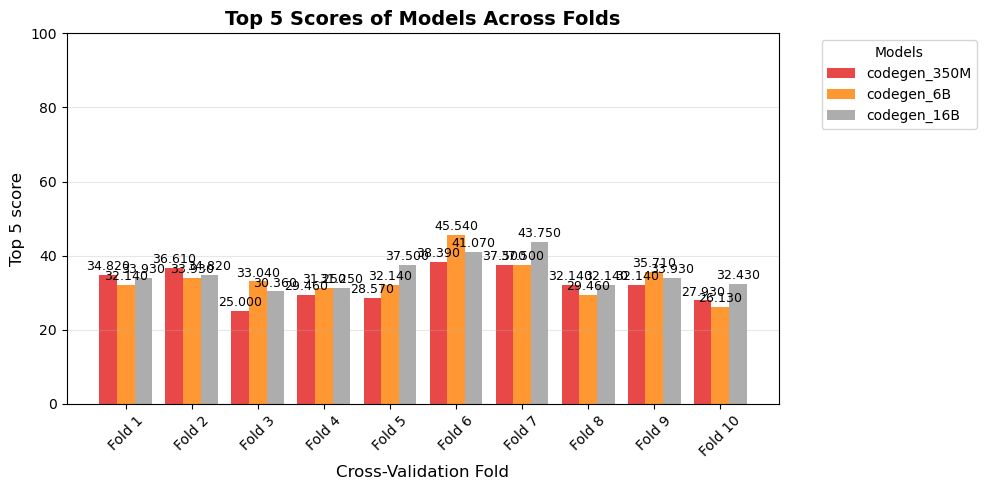

In [30]:
Helper.plot_grouped_bar_chart({'codegen_350M': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['top_5'],
                             'codegen_6B': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['top_5'],
                             'codegen_16B': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_5']},
                             title="Top 5 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 5 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1000)

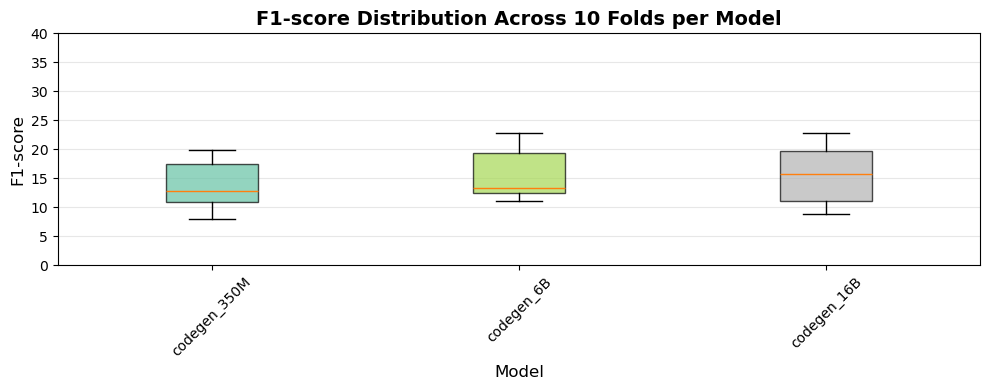

In [32]:
Helper.plot_boxplots({'codegen_350M': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['f1_score'],
                      'codegen_6B': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['f1_score'],
                      'codegen_16B': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['f1_score']},
                    fig_width=1000, fig_height=400, title="F1-score Distribution Across 10 Folds per Model", x_label="Model", y_label="F1-score", range_min=0.0, range_max=40.00)

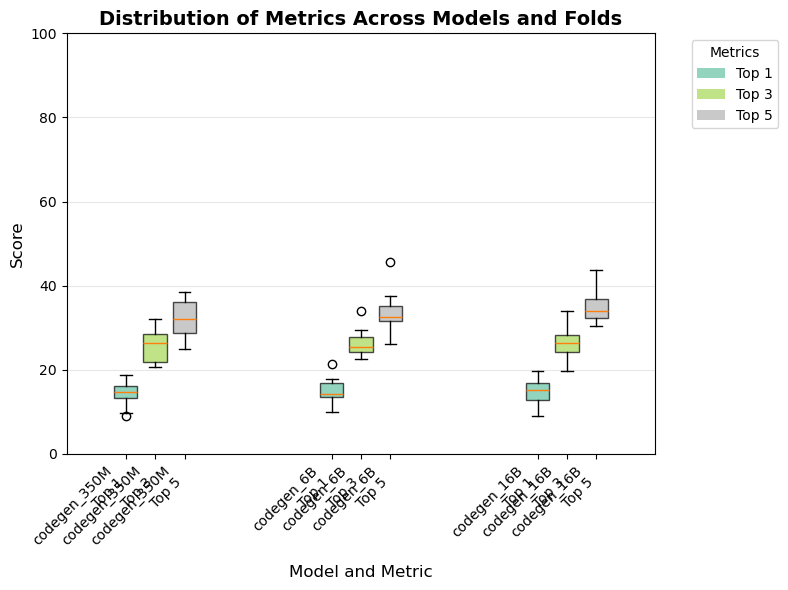

In [38]:
Helper.plot_grouped_boxplots({'codegen_350M': {'Top 1': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['top_1'],
                                               'Top 3': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['top_3'],
                                               'Top 5': experiment_results['defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE']['top_5']},
                      'codegen_6B': {'Top 1': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['top_1'],
                                     'Top 3': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['top_3'],
                                     'Top 5': experiment_results['defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE']['top_5']},
                      'codegen_16B': {'Top 1': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_1'],
                                      'Top 3': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_3'],
                                      'Top 5': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_5']}},
                    fig_width=800, fig_height=600, title="Distribution of Metrics Across Models and Folds", x_label="Model and Metric", y_label="Score", range_min=0.0, range_max=100.00)

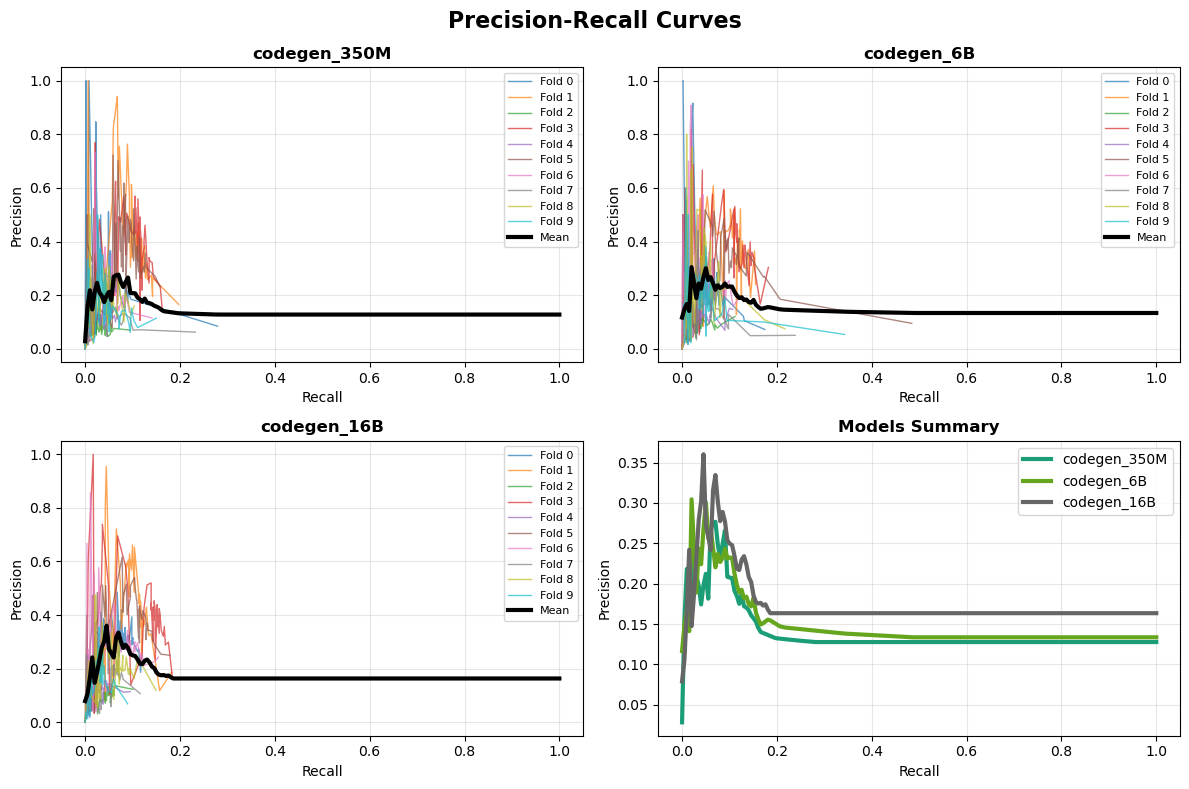

In [40]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = [
    'defects4j/v2/codegen_350M/exp1_defects4j_v2_1_linear_1024_1_BCE',
    'defects4j/v2/codegen_6B/exp1_defects4j_v2_2_linear_1024_1_BCE',
    'defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE'
]
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2]
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=800
    )

## Improvements(GRU, Reasoning models, Custom loss function) to base model architecture trained on Defects4j


Friedman Test: statistic = 25.0400, p = 0.0000

Average Ranks:
CodeGen-16B + Linear + BCE: 4.100
CodeGen-16B + GRU + BCE: 1.400
Qwen-QwQ-32B + Linear + BCE: 2.800
DeepSeek-R1-Distill-Llama-8B + Linear + BCE: 2.300
CodeGen-16B + Linear + Custom Loss: 4.400

Nemenyi Post-hoc Test (p-values):
                                             CodeGen-16B + Linear + BCE  \
CodeGen-16B + Linear + BCE                                     1.000000   
CodeGen-16B + GRU + BCE                                        0.001267   
Qwen-QwQ-32B + Linear + BCE                                    0.351295   
DeepSeek-R1-Distill-Llama-8B + Linear + BCE                    0.080831   
CodeGen-16B + Linear + Custom Loss                             0.993247   

                                             CodeGen-16B + GRU + BCE  \
CodeGen-16B + Linear + BCE                                  0.001267   
CodeGen-16B + GRU + BCE                                     1.000000   
Qwen-QwQ-32B + Linear + BCE              

D:\UoM\Final_Year_Project_New\vulnerability-detection-and-localization\llm-localizer\visualization_helper_functions_matplotlib.py:96: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


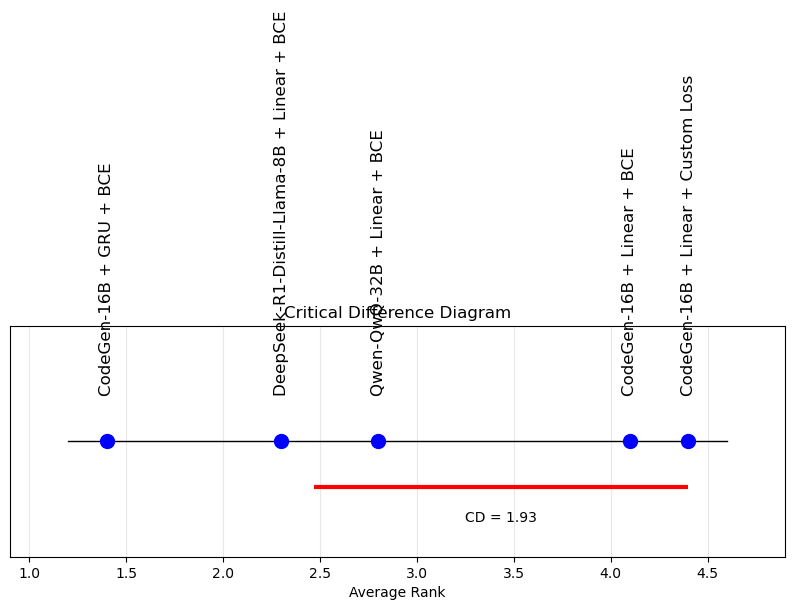

In [43]:
Helper.friedman_and_nemenyi({'CodeGen-16B + Linear + BCE': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + GRU + BCE': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['f1_score'],
                             'Qwen-QwQ-32B + Linear + BCE': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + Linear + BCE': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + Linear + Custom Loss': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['f1_score']},
                            fig_width=1000, fig_height=300)

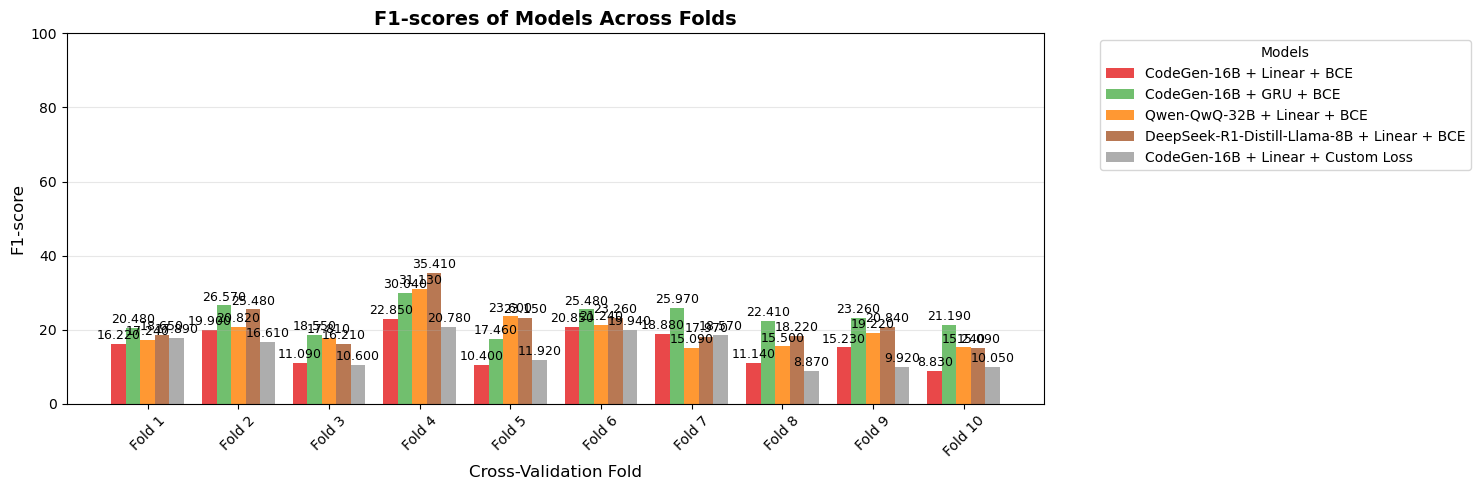

In [45]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + Linear + BCE': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + GRU + BCE': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['f1_score'],
                             'Qwen-QwQ-32B + Linear + BCE': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + Linear + BCE': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + Linear + Custom Loss': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['f1_score']},
                             title="F1-scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1500)

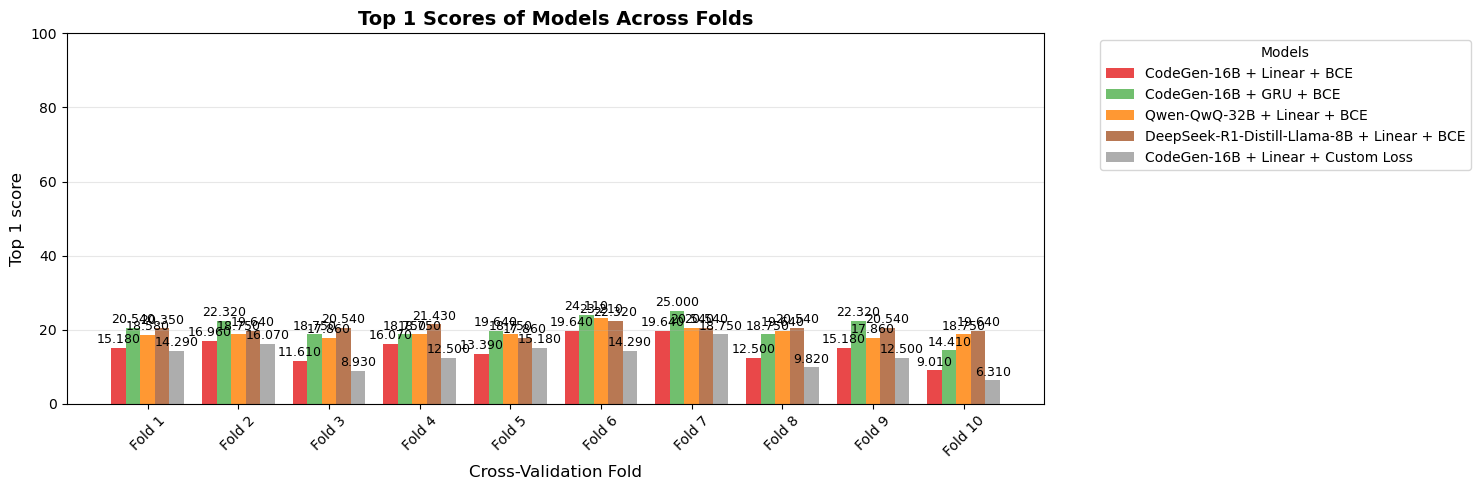

In [47]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + Linear + BCE': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_1'],
                             'CodeGen-16B + GRU + BCE': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['top_1'],
                             'Qwen-QwQ-32B + Linear + BCE': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['top_1'],
                             'DeepSeek-R1-Distill-Llama-8B + Linear + BCE': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['top_1'],
                             'CodeGen-16B + Linear + Custom Loss': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['top_1']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1500)

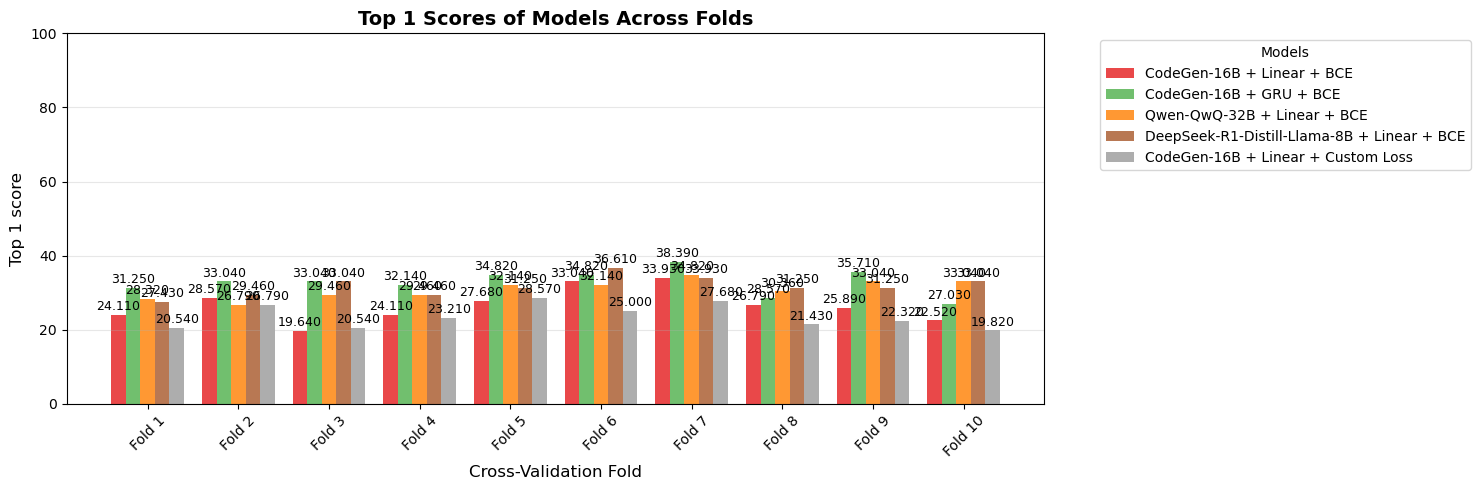

In [49]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + Linear + BCE': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_3'],
                             'CodeGen-16B + GRU + BCE': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['top_3'],
                             'Qwen-QwQ-32B + Linear + BCE': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['top_3'],
                             'DeepSeek-R1-Distill-Llama-8B + Linear + BCE': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['top_3'],
                             'CodeGen-16B + Linear + Custom Loss': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['top_3']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1500)

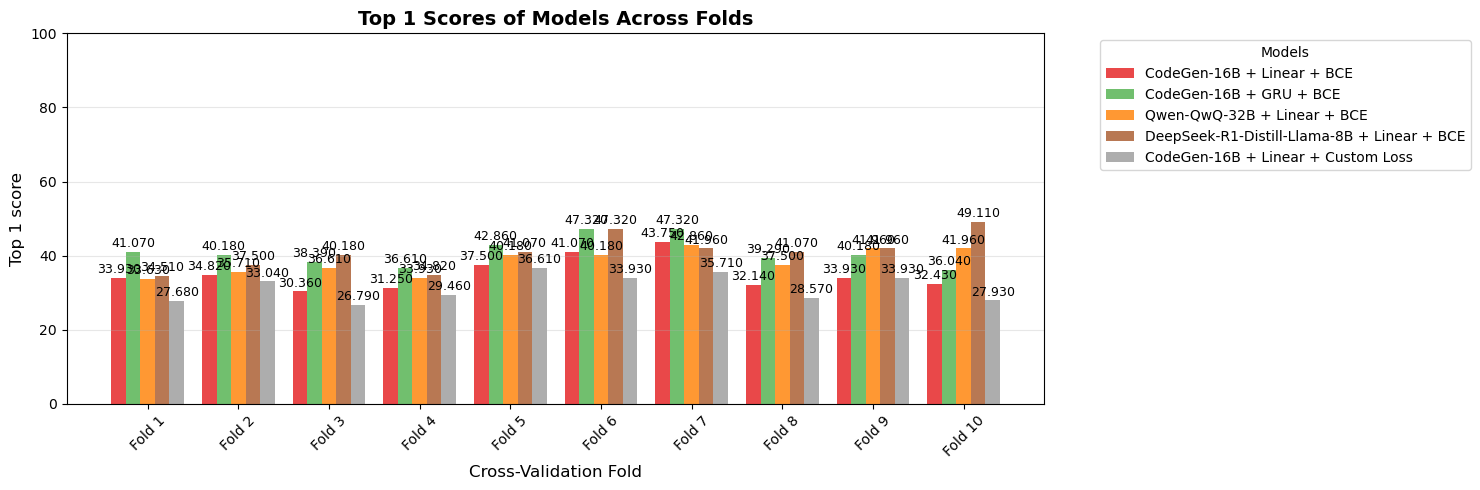

In [51]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + Linear + BCE': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_5'],
                             'CodeGen-16B + GRU + BCE': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['top_5'],
                             'Qwen-QwQ-32B + Linear + BCE': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['top_5'],
                             'DeepSeek-R1-Distill-Llama-8B + Linear + BCE': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['top_5'],
                             'CodeGen-16B + Linear + Custom Loss': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['top_5']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1500)

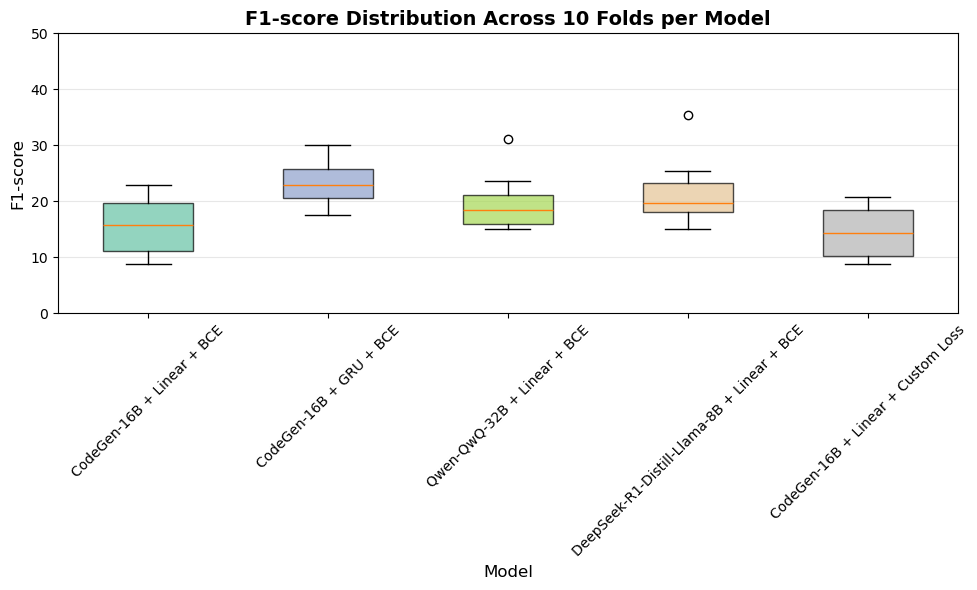

In [53]:
Helper.plot_boxplots({'CodeGen-16B + Linear + BCE': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + GRU + BCE': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['f1_score'],
                             'Qwen-QwQ-32B + Linear + BCE': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + Linear + BCE': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + Linear + Custom Loss': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['f1_score']},
                    fig_width=1000, fig_height=600, title="F1-score Distribution Across 10 Folds per Model", x_label="Model", y_label="F1-score", range_min=0.0, range_max=50.00)

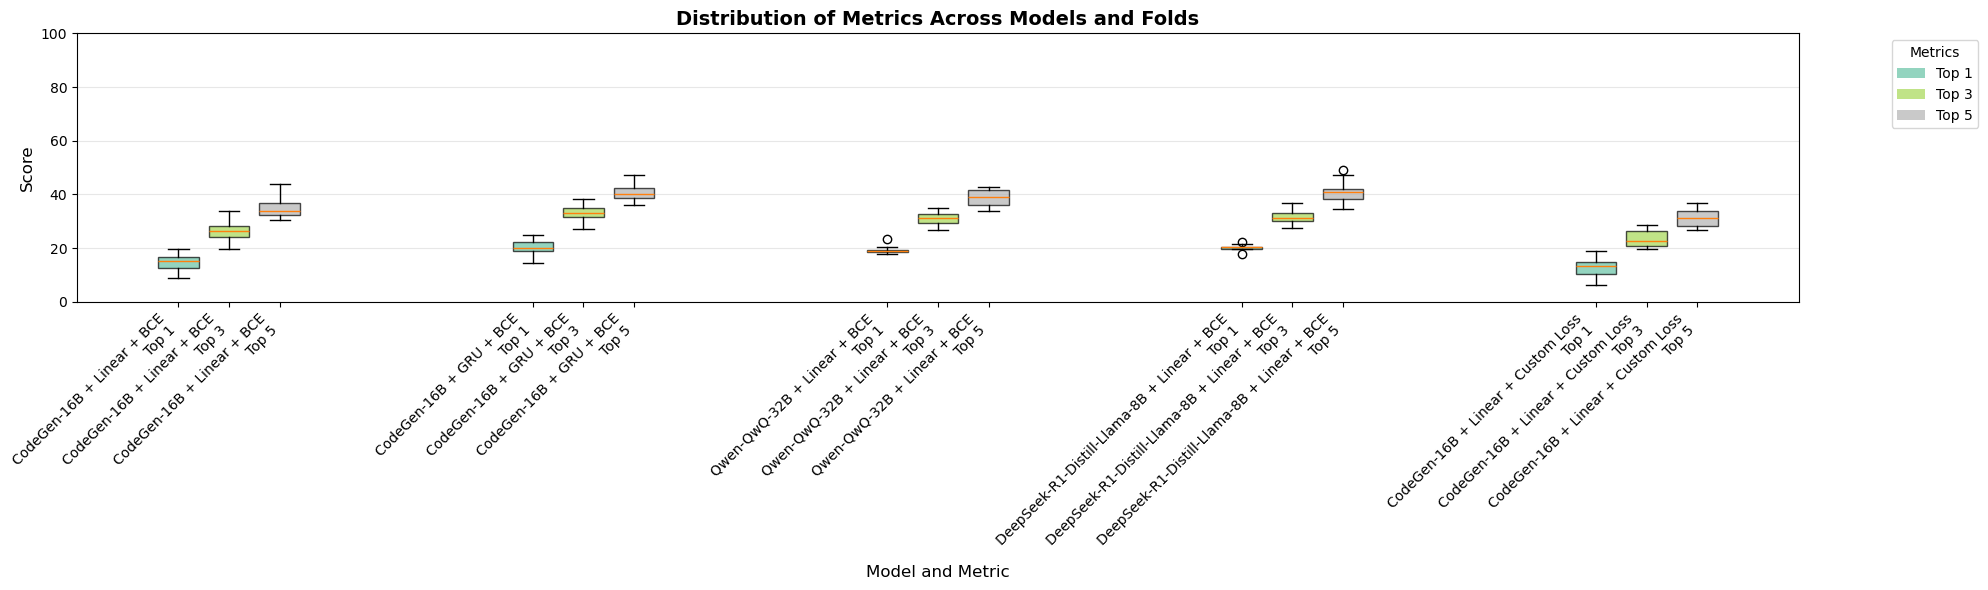

In [55]:
Helper.plot_grouped_boxplots({'CodeGen-16B + Linear + BCE': {'Top 1': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_1'],
                                               'Top 3': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_3'],
                                               'Top 5': experiment_results['defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE']['top_5']},
                      'CodeGen-16B + GRU + BCE': {'Top 1': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['top_1'],
                                     'Top 3': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['top_3'],
                                     'Top 5': experiment_results['defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE']['top_5']},
                      'Qwen-QwQ-32B + Linear + BCE': {'Top 1': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['top_1'],
                                      'Top 3': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['top_3'],
                                      'Top 5': experiment_results['defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE']['top_5']},
                              'DeepSeek-R1-Distill-Llama-8B + Linear + BCE': {'Top 1': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['top_1'],
                                      'Top 3': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['top_3'],
                                      'Top 5': experiment_results['defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE']['top_5']},
                              'CodeGen-16B + Linear + Custom Loss': {'Top 1': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['top_1'],
                                      'Top 3': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['top_3'],
                                      'Top 5': experiment_results['defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC']['top_5']}},
                    fig_width=2000, fig_height=600, title="Distribution of Metrics Across Models and Folds", x_label="Model and Metric", y_label="Score", range_min=0.0, range_max=100.00)

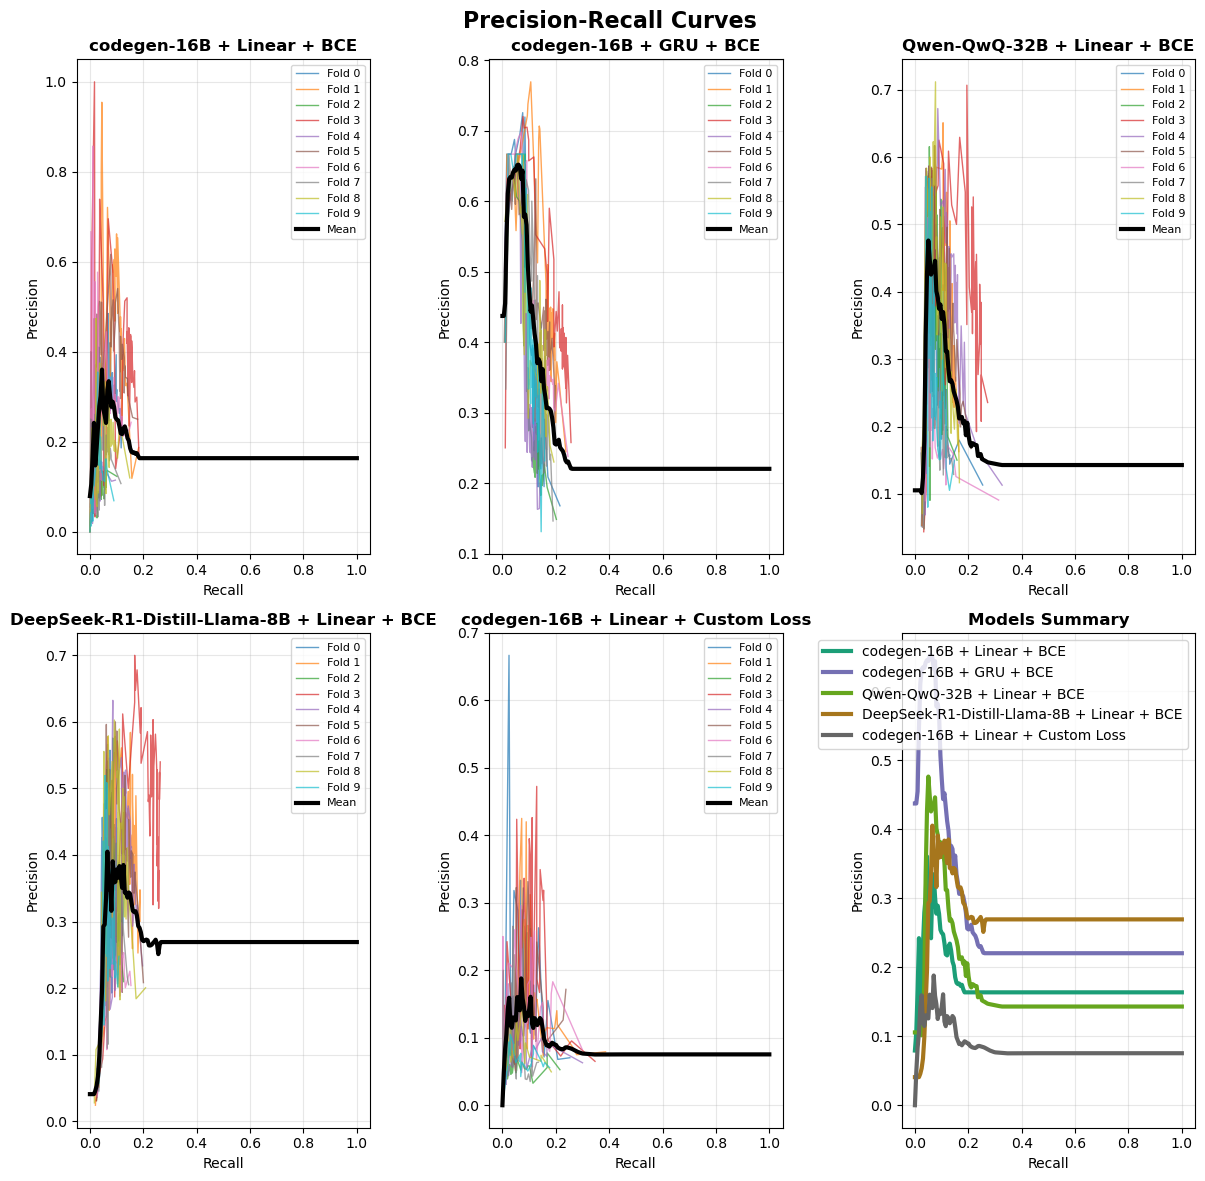

In [57]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = [
    'defects4j/v2/codegen_16B/exp1_defects4j_v2_3_linear_1024_1_BCE',
    'defects4j/v2/codegen_16B/exp2_defects4j_v2_3_gru_1024_1_BCE',
    'defects4j/v2/Qwen_QwQ_32B/exp3_defects4j_v2_17_linear_1024_1_BCE',
    'defects4j/v2/DeepSeek_R1_Distill_Llama_8B/exp4_defects4j_v2_18_linear_1024_1_BCE',
    'defects4j/v2/codegen_16B/exp5_defects4j_v2_3_linear_1024_1_CC'
]
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2].replace("_", "-")
    if 'linear' in experiment.split('/')[3]:
        model_name += " + Linear"
    if 'gru' in experiment.split('/')[3]:
        model_name += " + GRU"
    if 'BCE' in experiment.split('/')[3]:
        model_name += " + BCE"
    if 'CC' in experiment.split('/')[3]:
        model_name += " + Custom Loss"
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=1200
    )

## Improved model(Reasoning models and GRU) trained on Solidity localization dataset 

In [60]:
experiments = ['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']

In [62]:
Helper.friedman_and_nemenyi({'Qwen-QwQ-32B + GRU + BCE': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']},
                            fig_width=1000, fig_height=300)


Friedman Test: statistic = 0.6000, p = 0.7408

Average Ranks:
Qwen-QwQ-32B + GRU + BCE: 2.100
DeepSeek-R1-Distill-Llama-8B + GRU + BCE: 2.100
DeepSeek-R1-Distill-Qwen-14B + GRU + BCE: 1.800

No significant difference found (p >= 0.05).


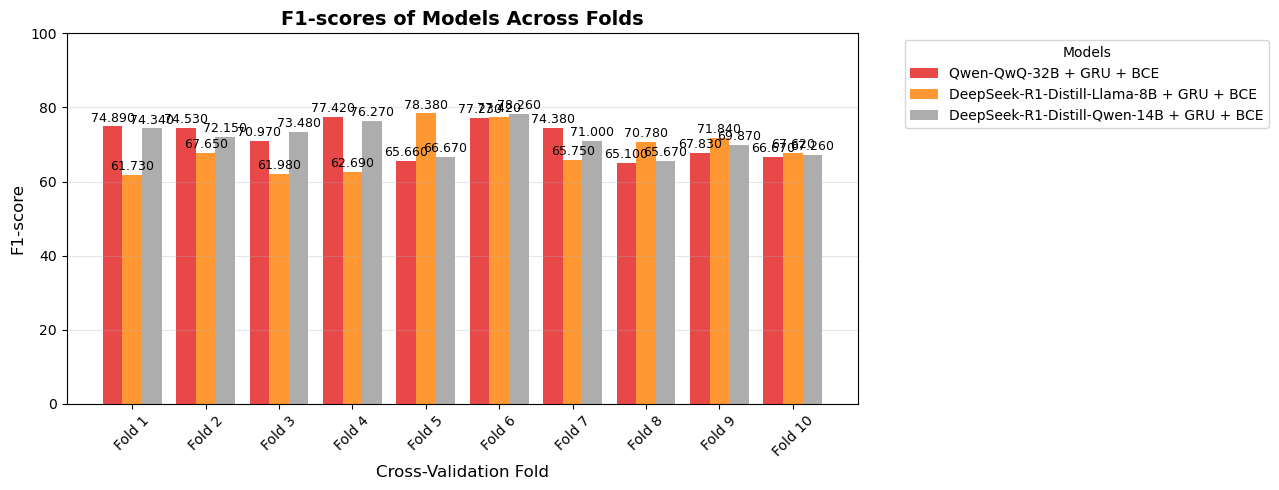

In [64]:
Helper.plot_grouped_bar_chart({'Qwen-QwQ-32B + GRU + BCE': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']},
                             title="F1-scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

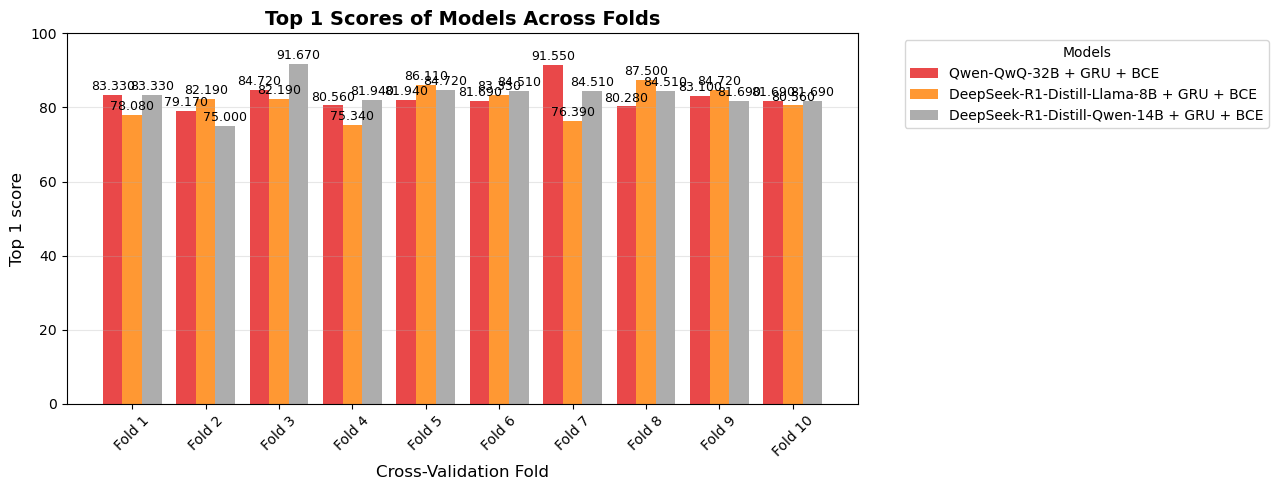

In [66]:
Helper.plot_grouped_bar_chart({'Qwen-QwQ-32B + GRU + BCE': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_1'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_1'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_1']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

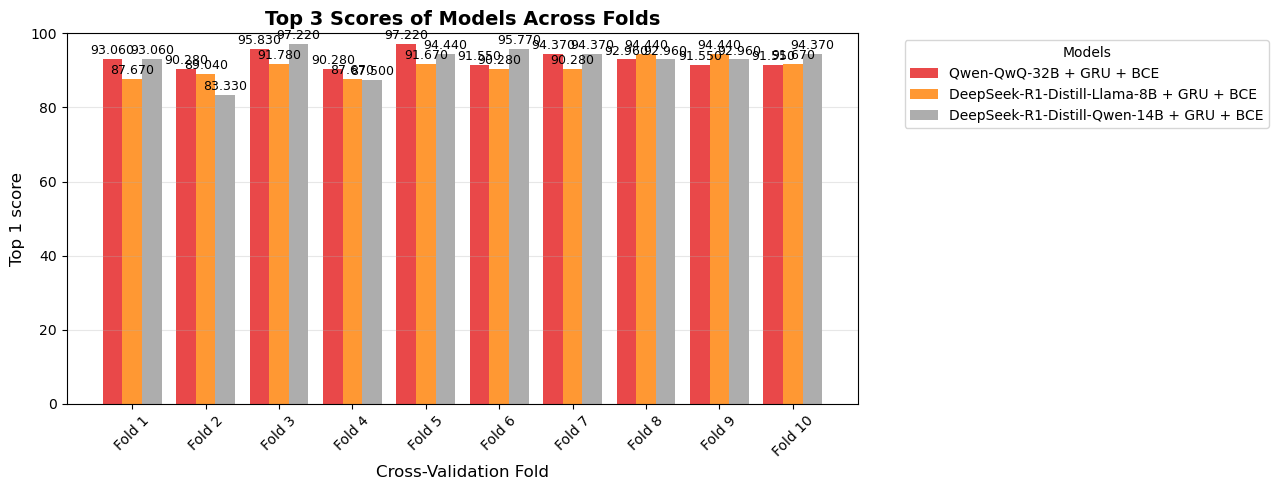

In [68]:
Helper.plot_grouped_bar_chart({'Qwen-QwQ-32B + GRU + BCE': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_3'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_3'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_3']},
                             title="Top 3 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

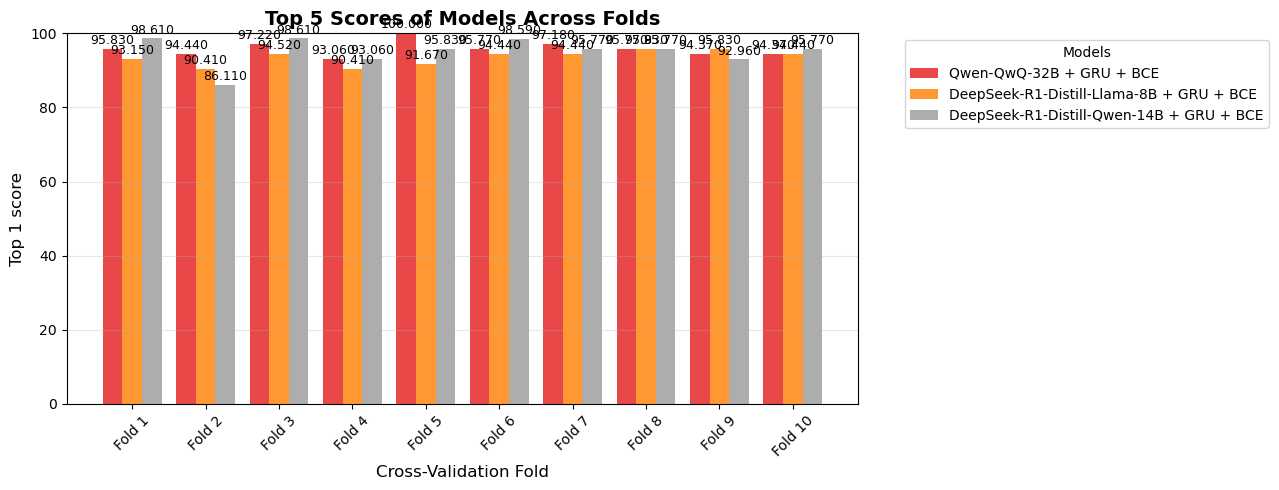

In [70]:
Helper.plot_grouped_bar_chart({'Qwen-QwQ-32B + GRU + BCE': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_5'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_5'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_5']},
                             title="Top 5 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

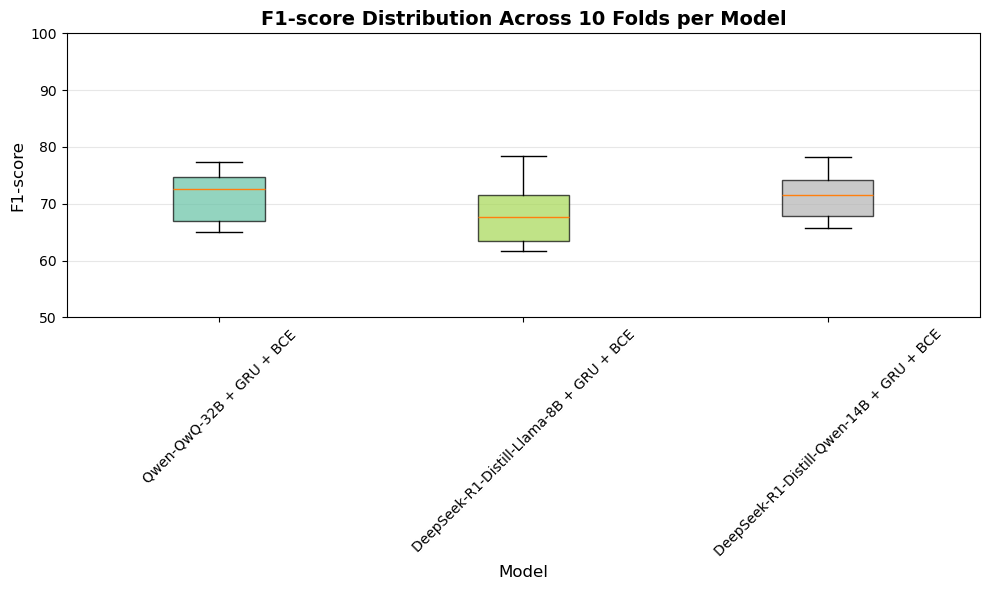

In [72]:
Helper.plot_boxplots({'Qwen-QwQ-32B + GRU + BCE': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']},
                    fig_width=1000, fig_height=600, title="F1-score Distribution Across 10 Folds per Model", x_label="Model", y_label="F1-score", range_min=50.0, range_max=100.00)

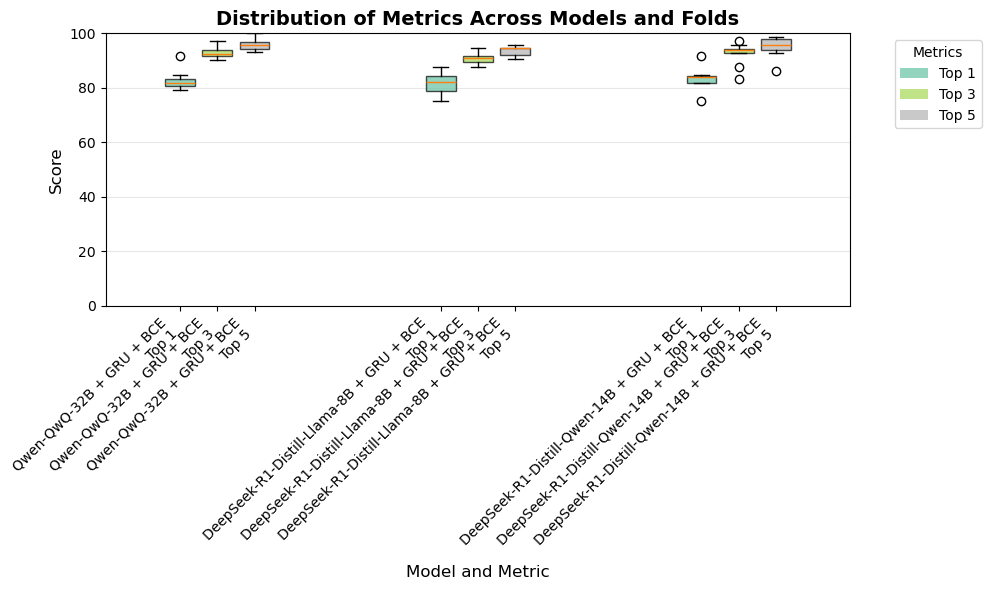

In [74]:
Helper.plot_grouped_boxplots({'Qwen-QwQ-32B + GRU + BCE': {'Top 1': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_1'],
                                               'Top 3': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_3'],
                                               'Top 5': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_5']},
                      'DeepSeek-R1-Distill-Llama-8B + GRU + BCE': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_1'],
                                     'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_3'],
                                     'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_5']},
                      'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_1'],
                                      'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_3'],
                                      'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_5']}},
                    fig_width=1000, fig_height=600, title="Distribution of Metrics Across Models and Folds", x_label="Model and Metric", y_label="Score", range_min=0.0, range_max=100.00)

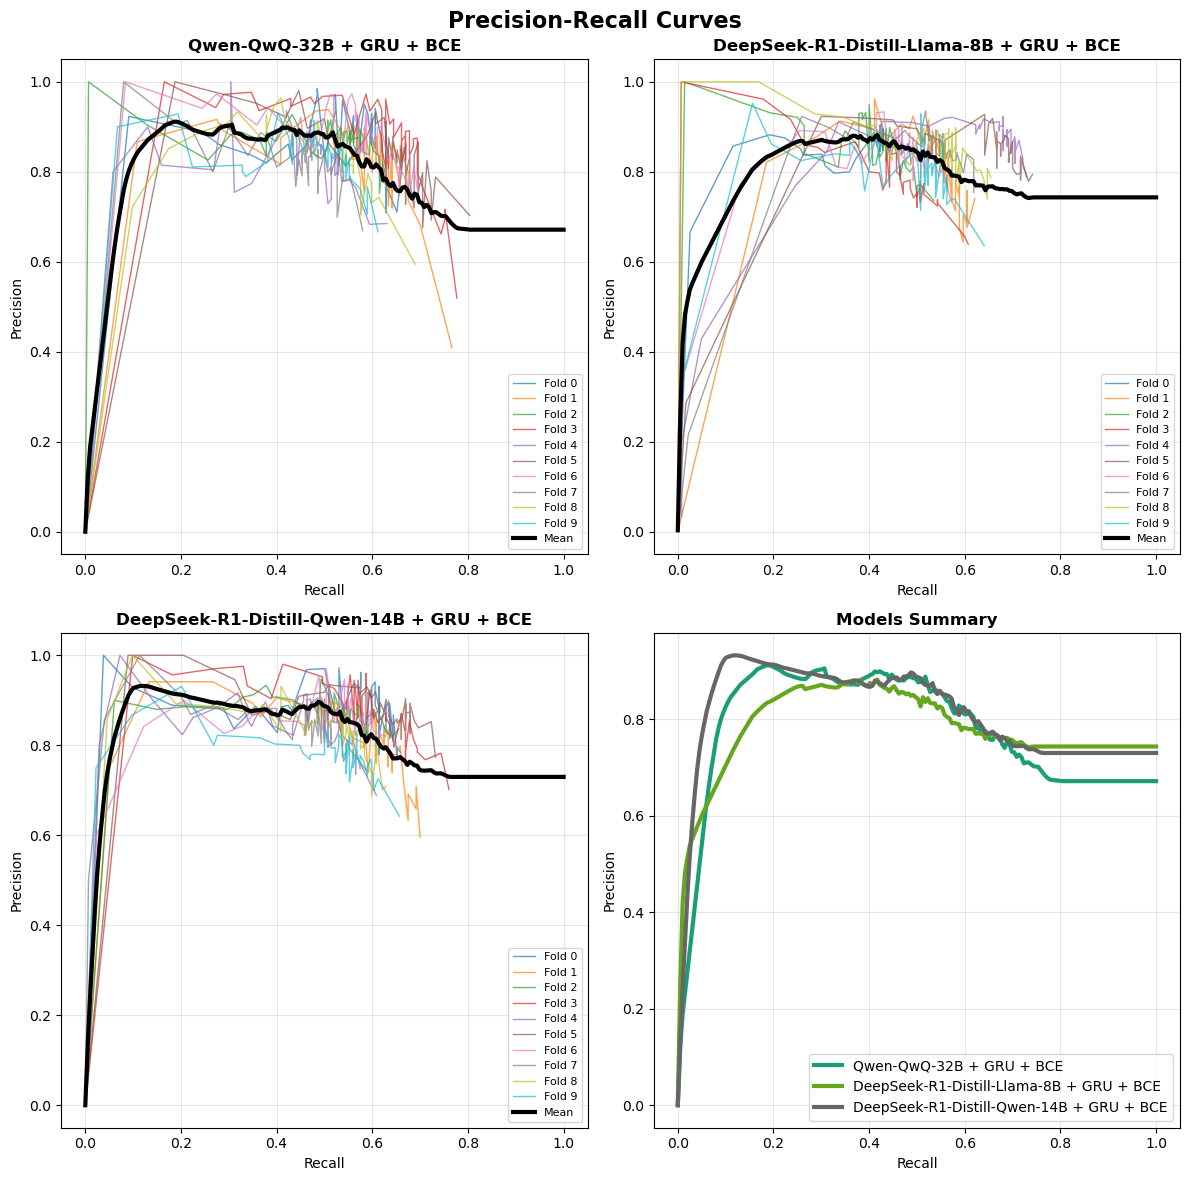

In [76]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = [
    'solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE',
    'solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE',
    'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE'
]
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2].replace("_", "-")
    if 'linear' in experiment.split('/')[3]:
        model_name += " + Linear"
    if 'gru' in experiment.split('/')[3]:
        model_name += " + GRU"
    if 'BCE' in experiment.split('/')[3]:
        model_name += " + BCE"
    if 'CC' in experiment.split('/')[3]:
        model_name += " + Custom Loss"
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=1200
    )

## Ablation test on improved model trained on Solidity localization dataset

In [79]:
Helper.compare_two_models({'CodeGen-16B + GRU + BCE': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']})

Wilcoxon statistic = 0.000, p-value = 0.0020
Statistically significant — meaning one model performs better consistently across folds
Mean F1 difference (CodeGen-16B + GRU + BCE - DeepSeek-R1-Distill-Qwen-14B + GRU + BCE): -13.1160
DeepSeek-R1-Distill-Qwen-14B + GRU + BCE is better on average


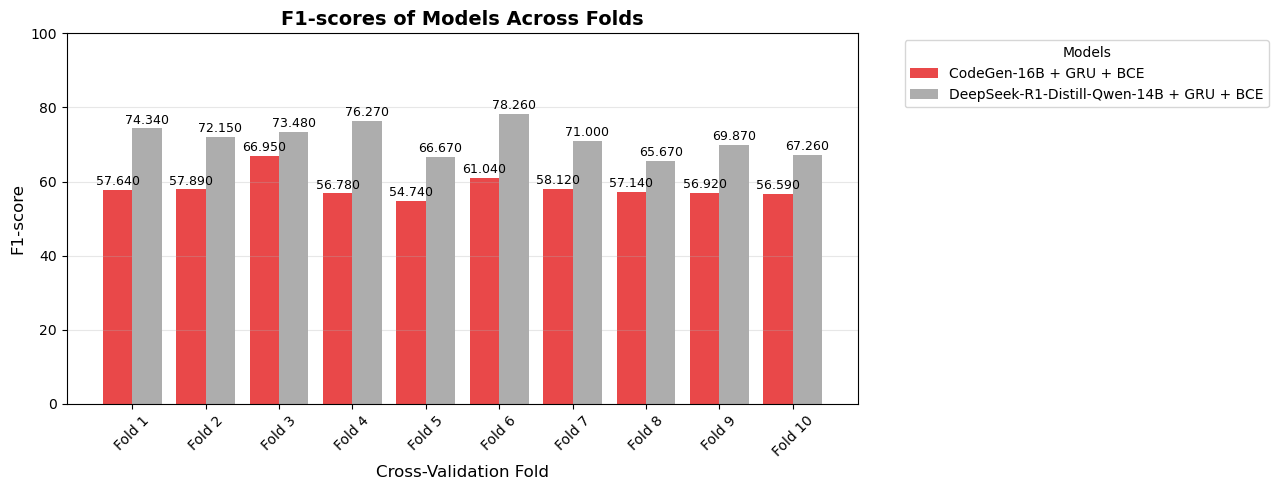

In [81]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + GRU + BCE': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']},
                             title="F1-scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

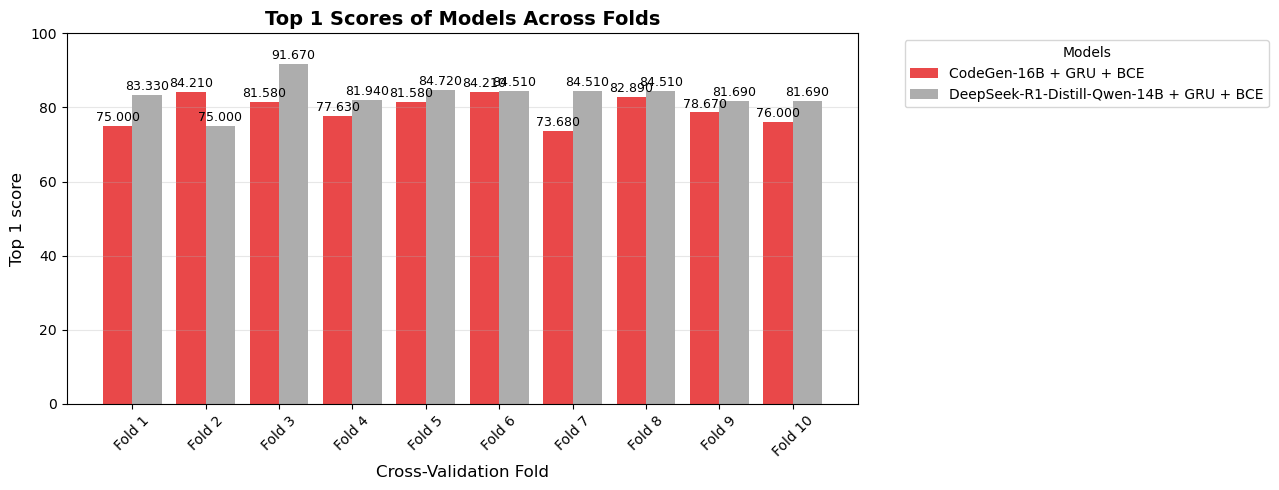

In [83]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + GRU + BCE': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_1'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_1']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

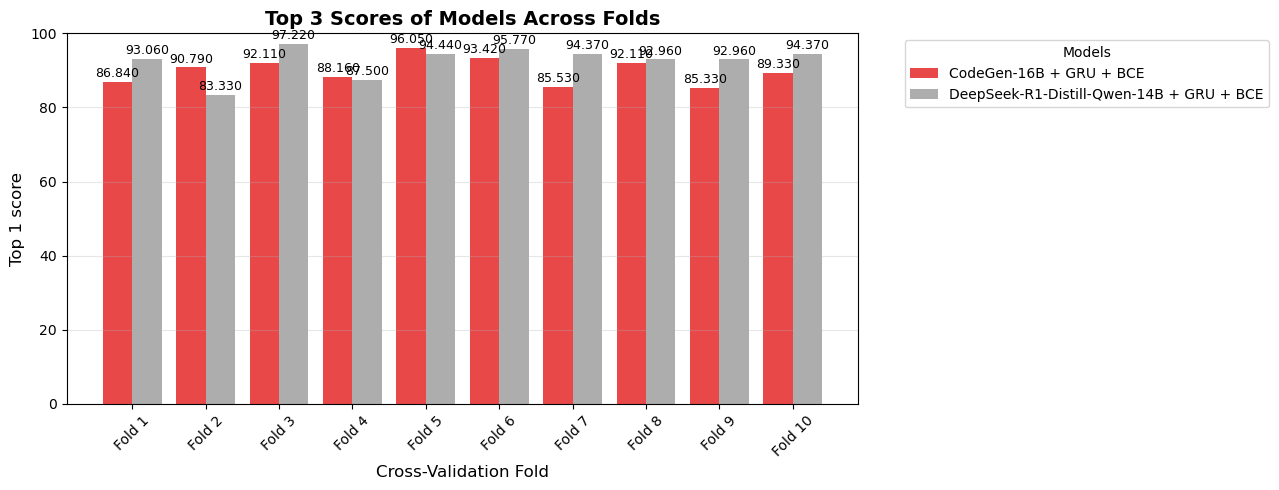

In [85]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + GRU + BCE': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_3'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_3']},
                             title="Top 3 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

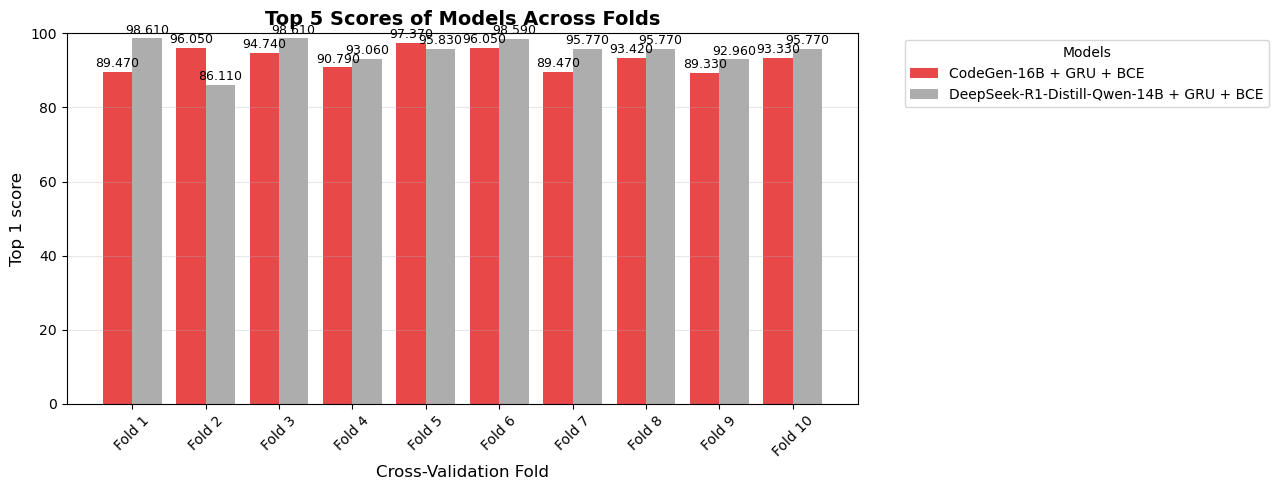

In [87]:
Helper.plot_grouped_bar_chart({'CodeGen-16B + GRU + BCE': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_5'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_5']},
                             title="Top 5 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="Top 1 score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

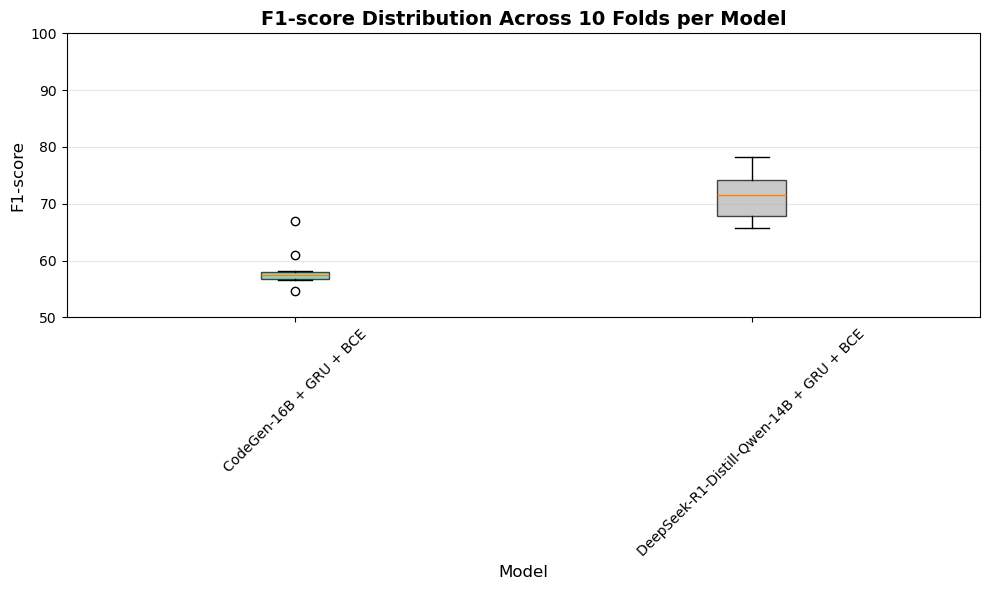

In [89]:
Helper.plot_boxplots({'CodeGen-16B + GRU + BCE': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']},
                    fig_width=1000, fig_height=600, title="F1-score Distribution Across 10 Folds per Model", x_label="Model", y_label="F1-score", range_min=50.0, range_max=100.00)

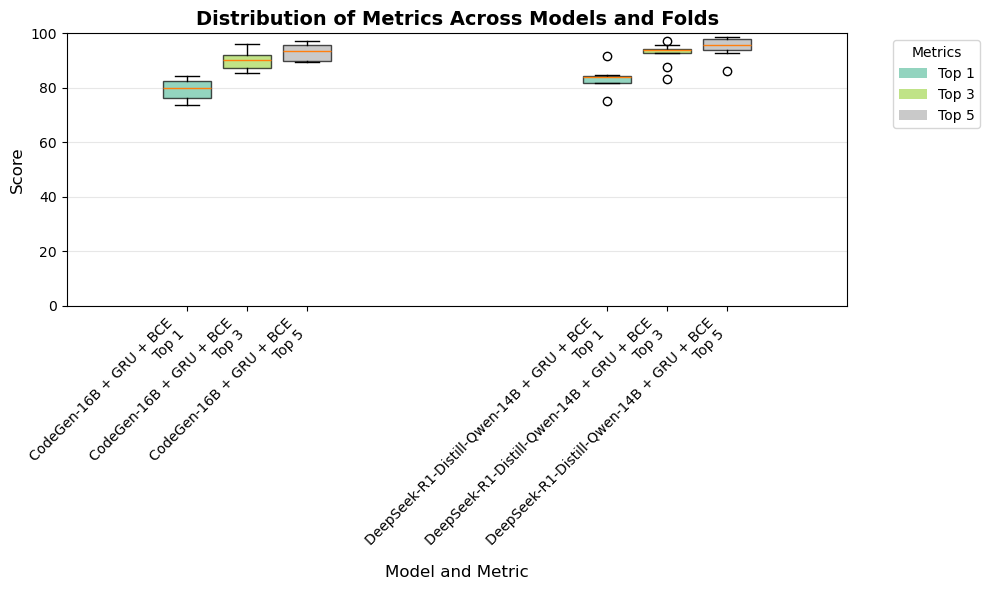

In [91]:
Helper.plot_grouped_boxplots({'CodeGen-16B + GRU + BCE': {'Top 1': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_1'],
                                               'Top 3': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_3'],
                                               'Top 5': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_5']},
                      'DeepSeek-R1-Distill-Qwen-14B + GRU + BCE': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_1'],
                                      'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_3'],
                                      'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_5']}},
                    fig_width=1000, fig_height=600, title="Distribution of Metrics Across Models and Folds", x_label="Model and Metric", y_label="Score", range_min=0.0, range_max=100.00)

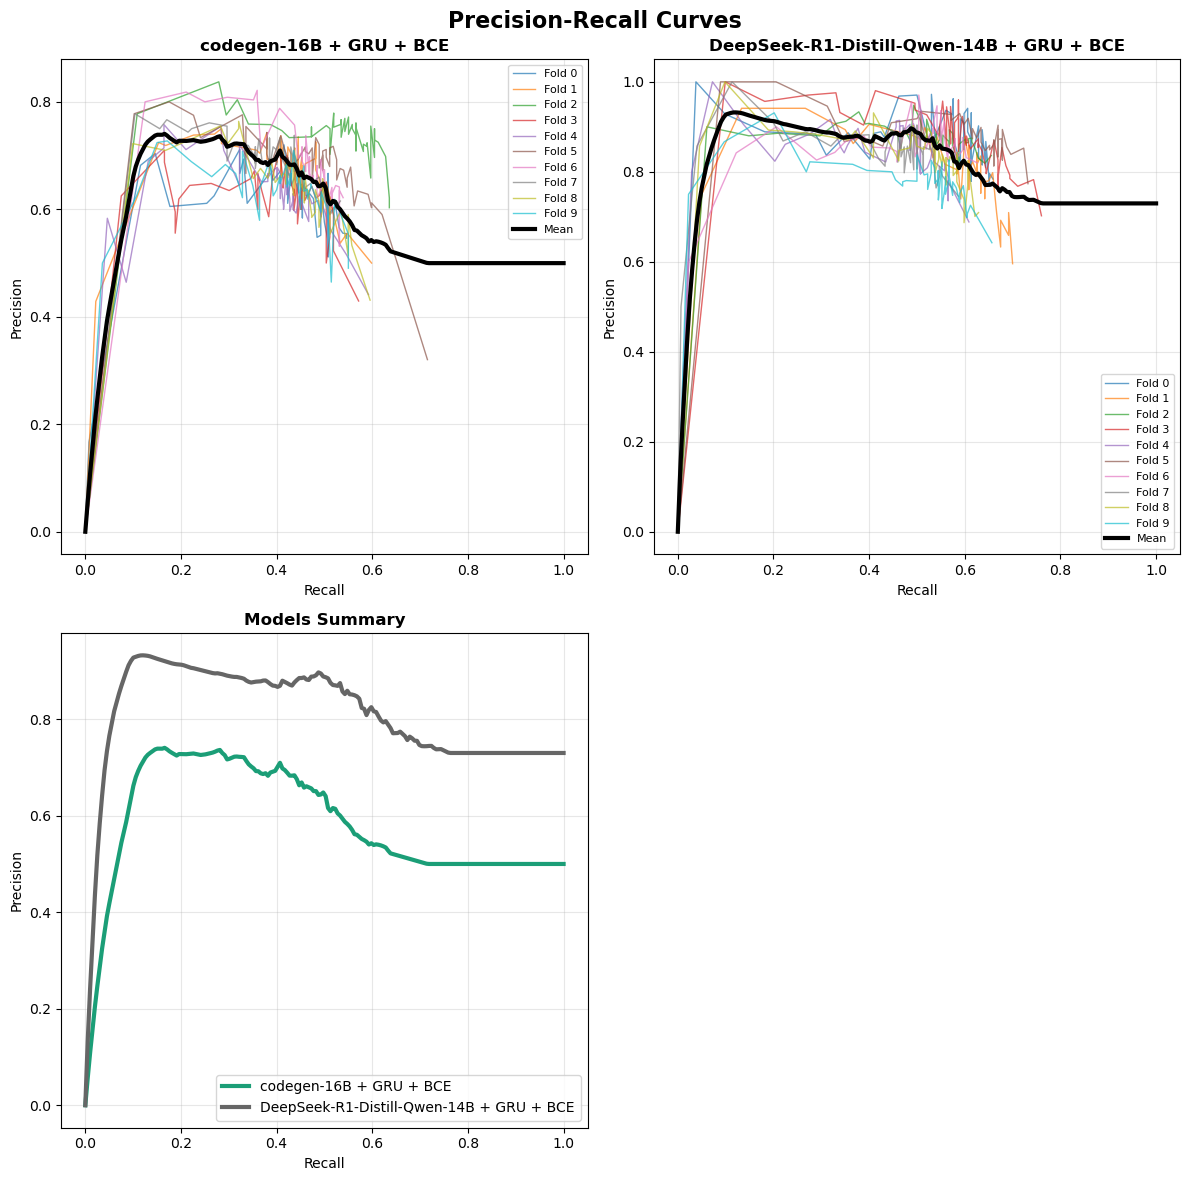

In [93]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = [
    'solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE',
    'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE'
]
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2].replace("_", "-")
    if 'linear' in experiment.split('/')[3]:
        model_name += " + Linear"
    if 'gru' in experiment.split('/')[3]:
        model_name += " + GRU"
    if 'BCE' in experiment.split('/')[3]:
        model_name += " + BCE"
    if 'CC' in experiment.split('/')[3]:
        model_name += " + Custom Loss"
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=1200
    )

## Test different model configuration for improved model trained on Solidity localization dataset

In [96]:
Helper.compare_two_models({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']})

Wilcoxon statistic = 12.000, p-value = 0.1309
No significant difference
Mean F1 difference (DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE - DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE): -3.3320
DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE is better on average


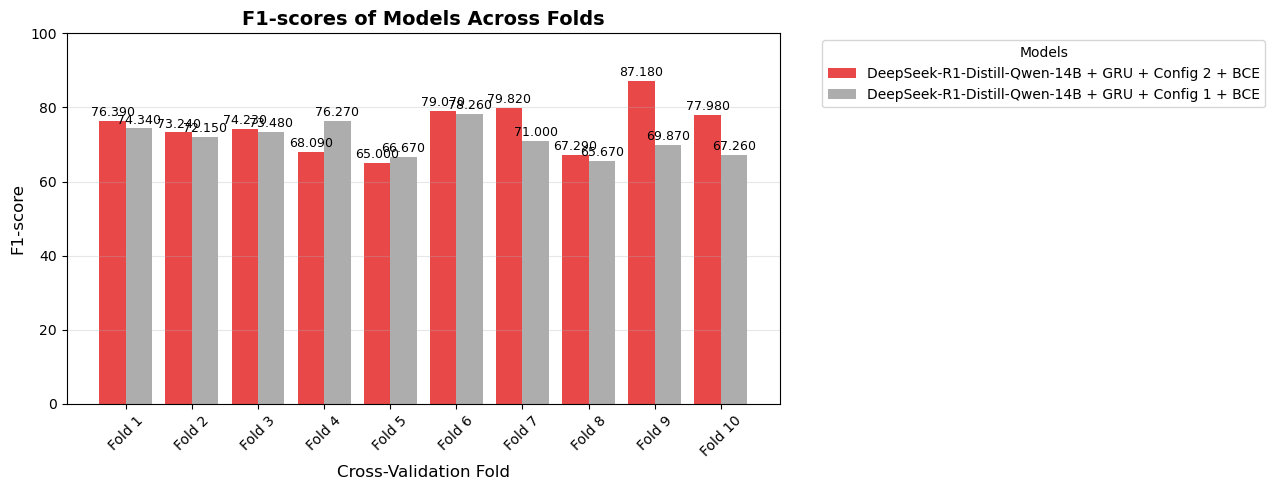

In [98]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']},
                             title="F1-scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

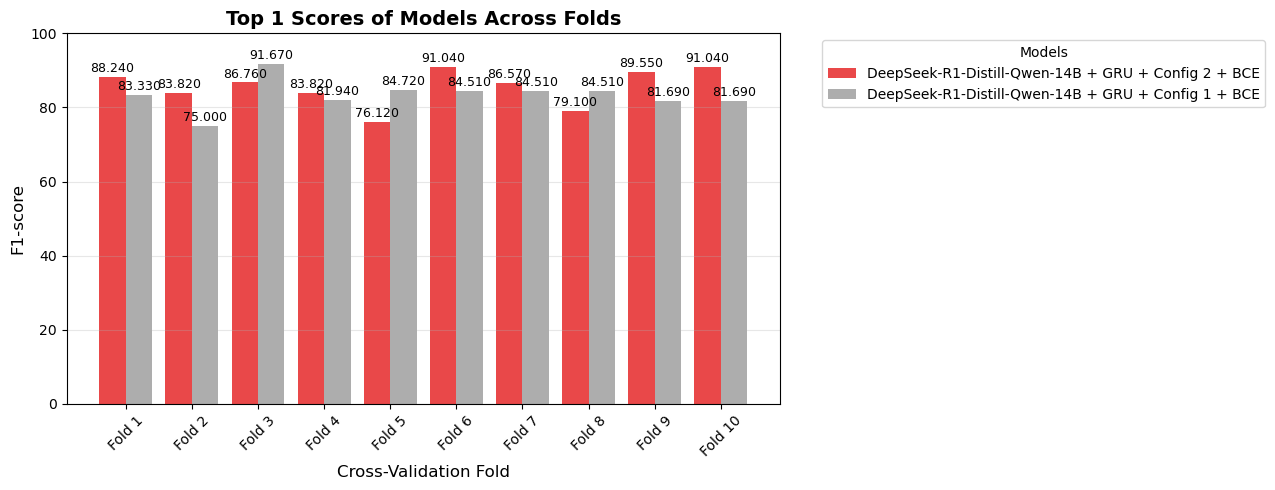

In [100]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_1'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_1']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

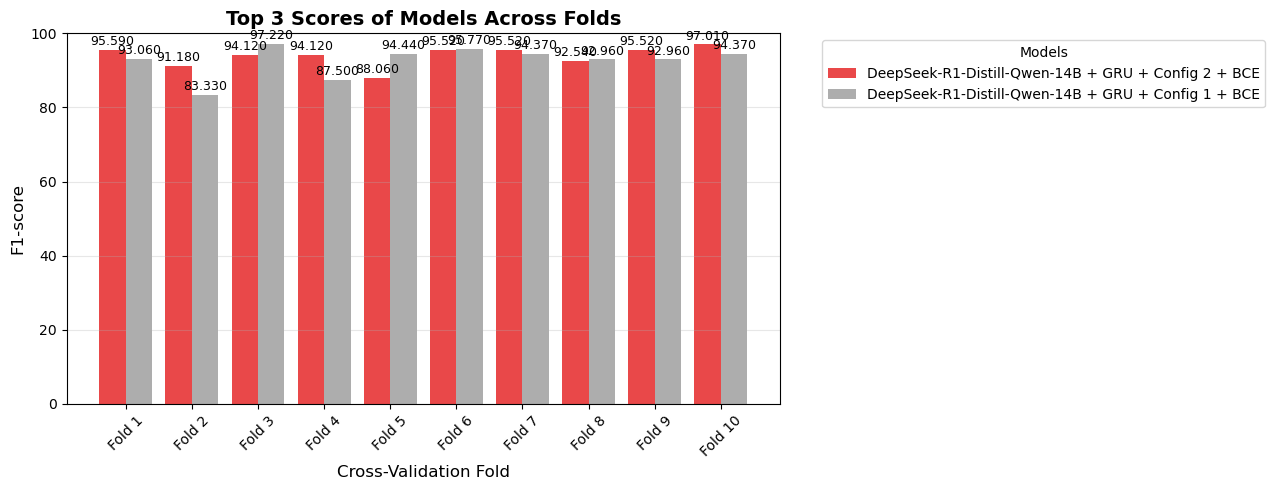

In [102]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_3'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_3']},
                             title="Top 3 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

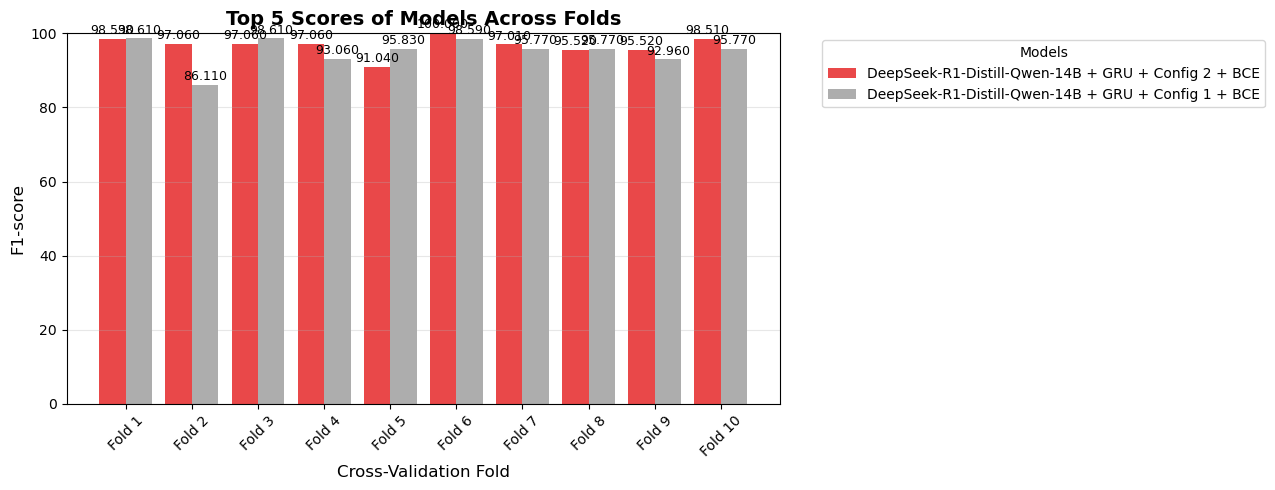

In [104]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_5'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_5']},
                             title="Top 5 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

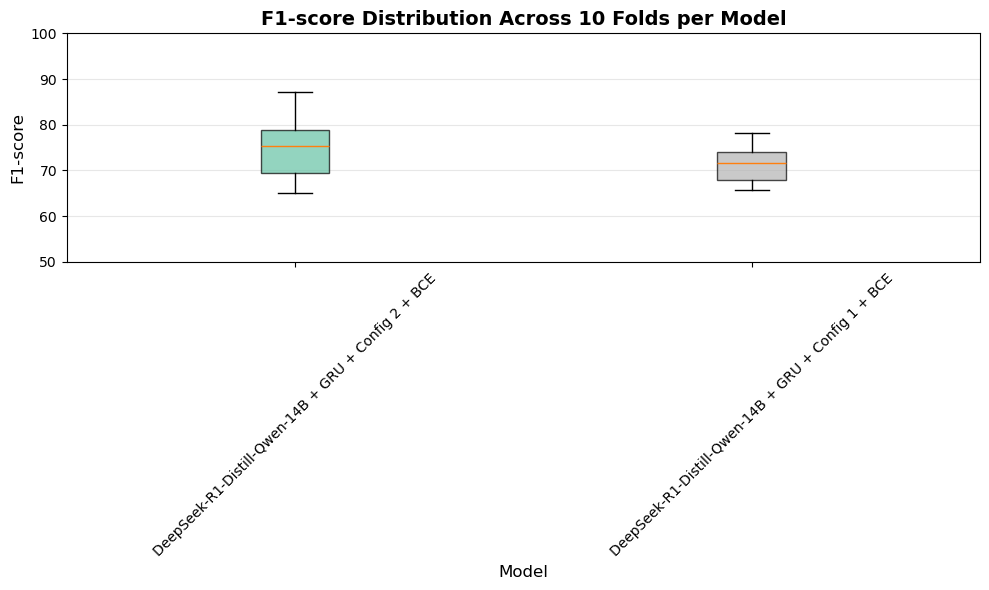

In [106]:
Helper.plot_boxplots({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score']},
                    fig_width=1000, fig_height=600, title="F1-score Distribution Across 10 Folds per Model", x_label="Model", y_label="F1-score", range_min=50.0, range_max=100.00)

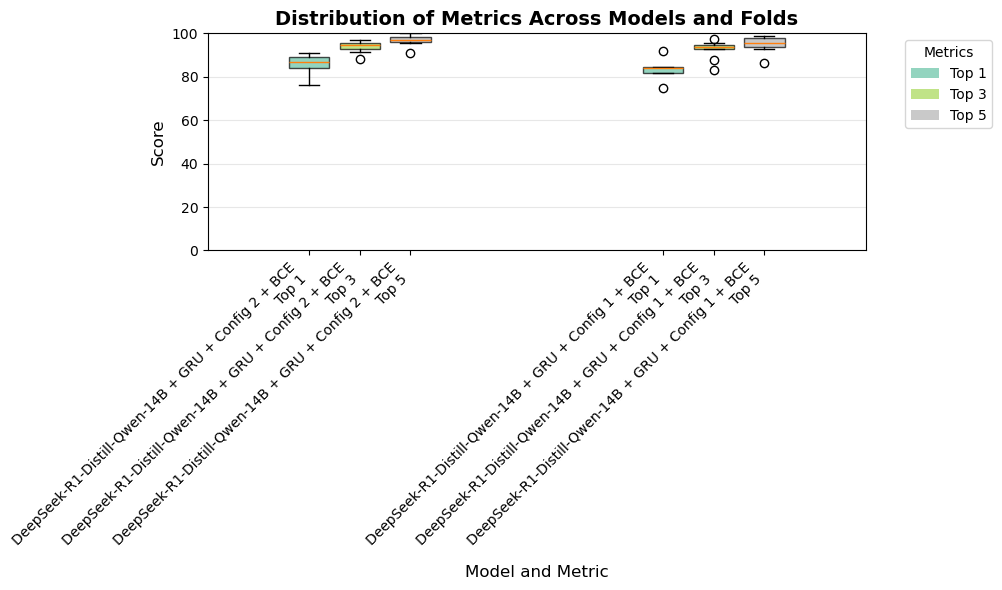

In [108]:
Helper.plot_grouped_boxplots({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_1'],
                                               'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_3'],
                                               'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_5']},
                      'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1 + BCE': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_1'],
                                      'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_3'],
                                      'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_5']}},
                    fig_width=1000, fig_height=600, title="Distribution of Metrics Across Models and Folds", x_label="Model and Metric", y_label="Score", range_min=0.0, range_max=100.00)

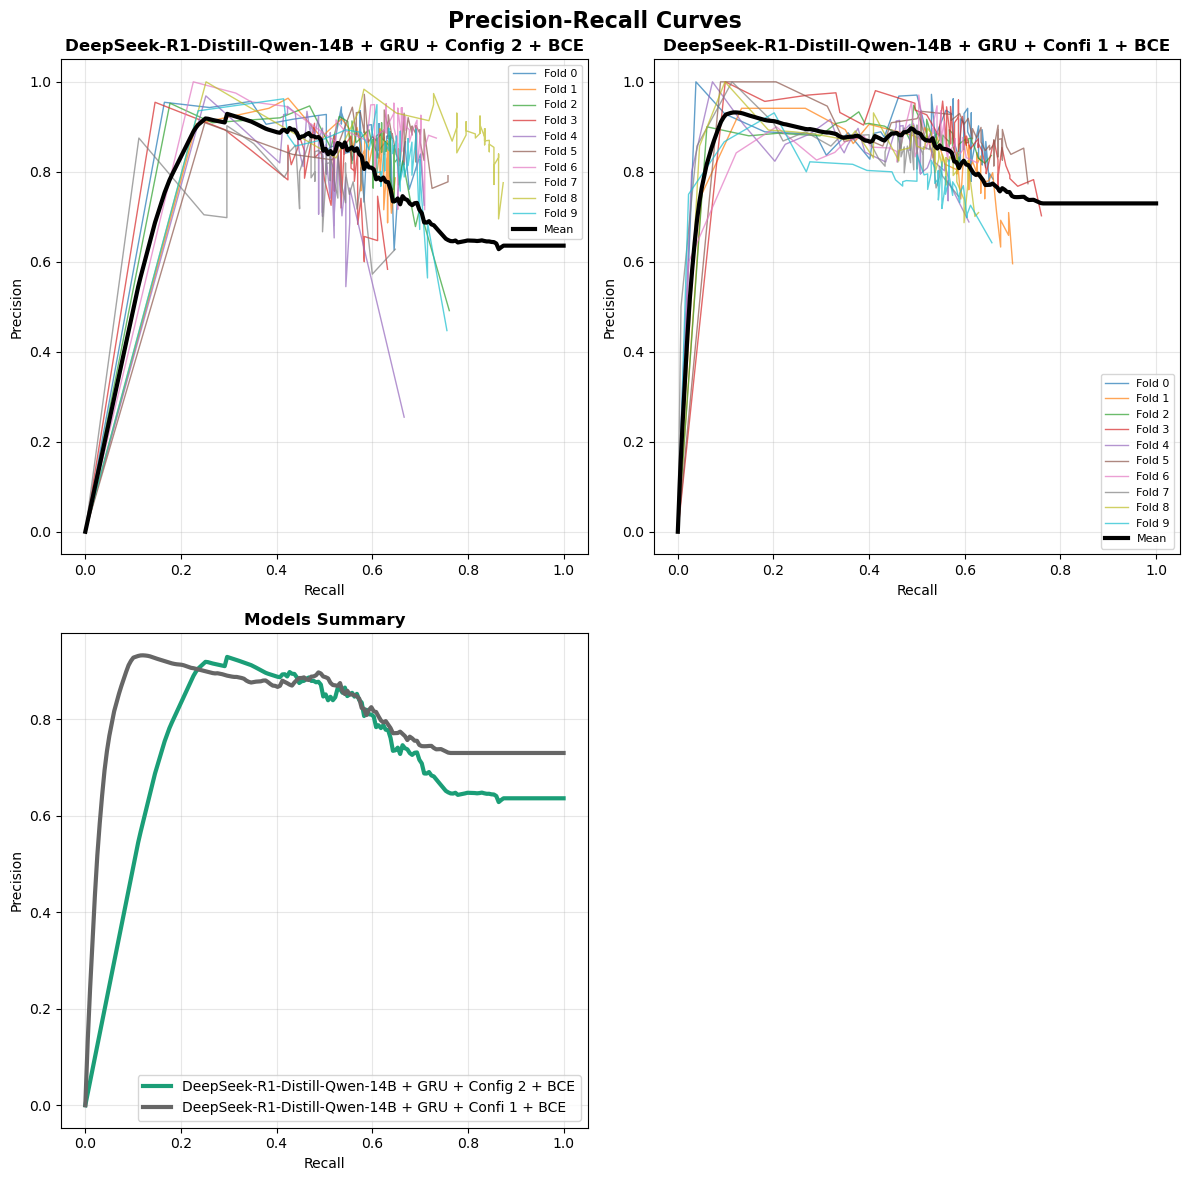

In [110]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = [
    'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE',
    'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE'
]
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2].replace("_", "-")
    if 'linear' in experiment.split('/')[3]:
        model_name += " + Linear"
    if 'gru' in experiment.split('/')[3]:
        model_name += " + GRU"
    if '1' in experiment.split('/')[3].split('_')[6]:
        model_name += " + Confi 1"
    if '2' in experiment.split('/')[3].split('_')[6]:
        model_name += " + Config 2"
    if 'BCE' in experiment.split('/')[3]:
        model_name += " + BCE"
    if 'CC' in experiment.split('/')[3]:
        model_name += " + Custom Loss"
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=1200
    )

## Test the impact of prompt for the improved model trained on Solidity localization dataset

In [113]:
Helper.compare_two_models({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['f1_score'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score']})

Wilcoxon statistic = 0.000, p-value = 0.0020
Statistically significant — meaning one model performs better consistently across folds
Mean F1 difference (DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt) - DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)): -7.3970
DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt) is better on average


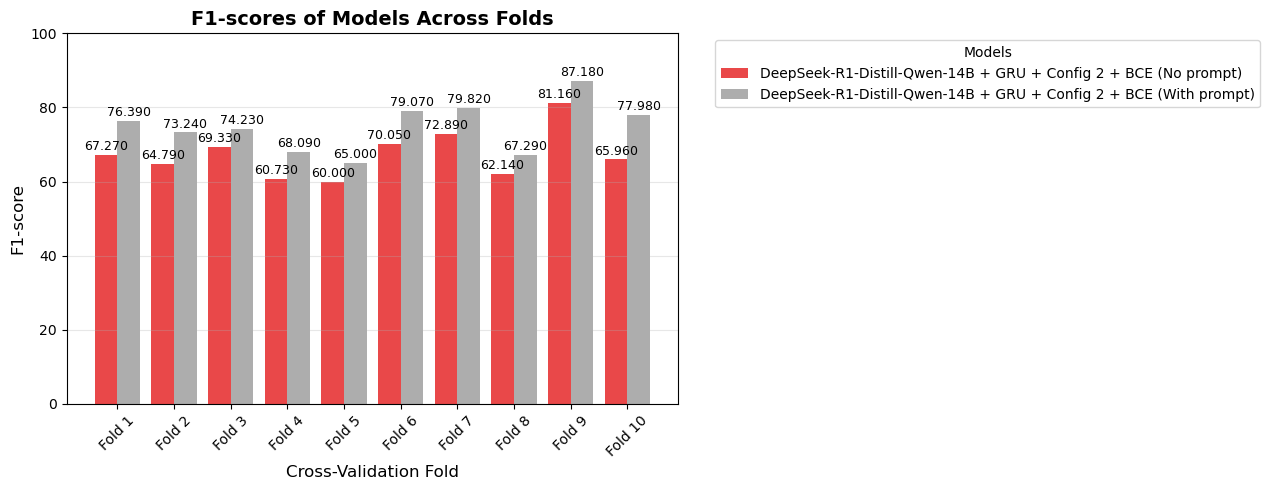

In [115]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['f1_score'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score']},
                             title="F1-scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

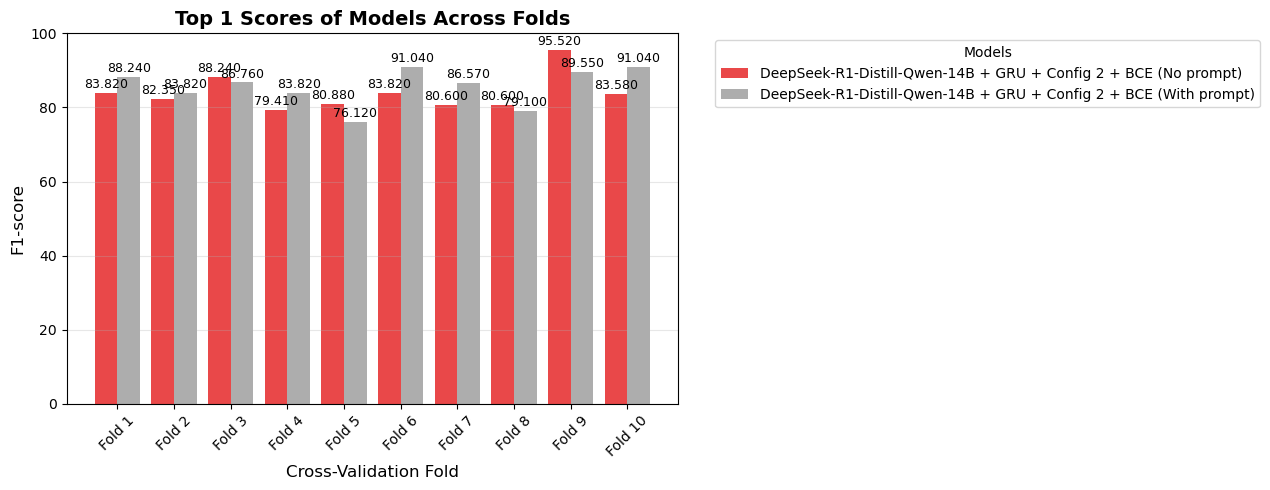

In [117]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_1'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_1']},
                             title="Top 1 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

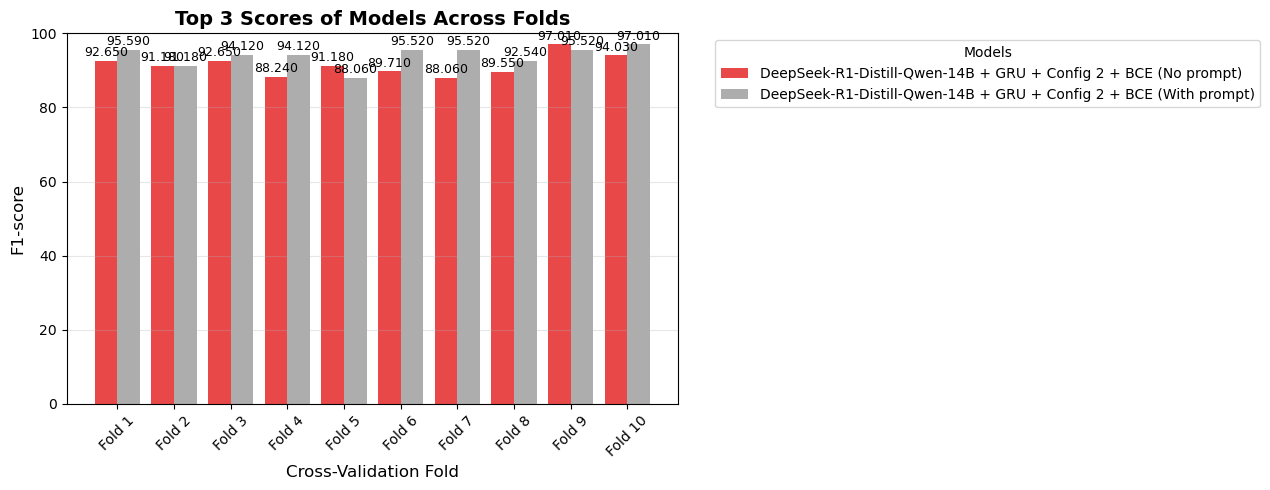

In [119]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_3'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_3']},
                             title="Top 3 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

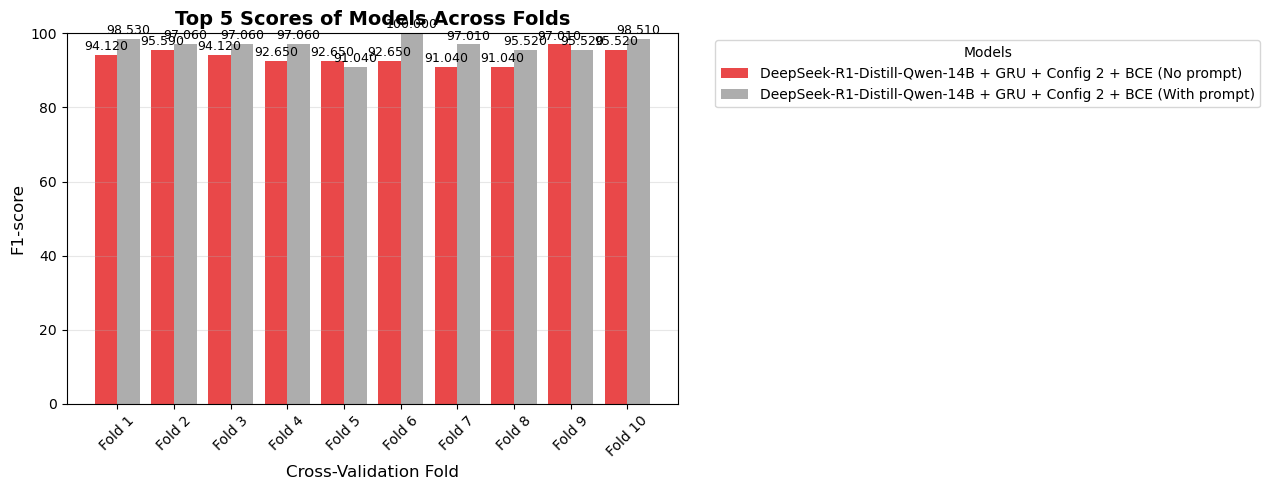

In [121]:
Helper.plot_grouped_bar_chart({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_5'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_5']},
                             title="Top 5 Scores of Models Across Folds", x_label="Cross-Validation Fold", y_label="F1-score", range_min=0.0, range_max=100.0, fig_height=500, fig_width=1300)

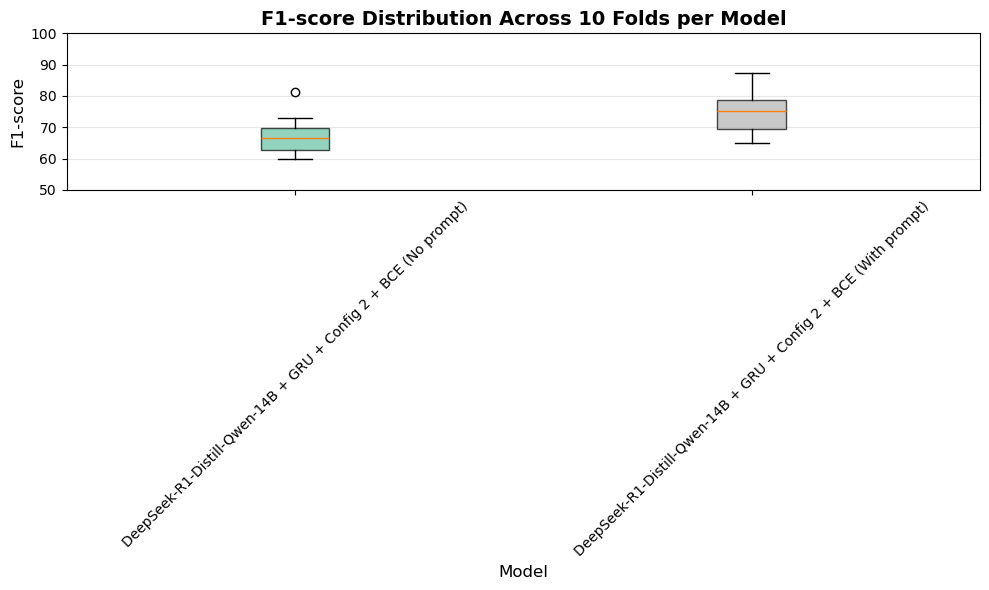

In [123]:
Helper.plot_boxplots({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['f1_score'], 
                           'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score']},
                    fig_width=1000, fig_height=600, title="F1-score Distribution Across 10 Folds per Model", x_label="Model", y_label="F1-score", range_min=50.0, range_max=100.00)

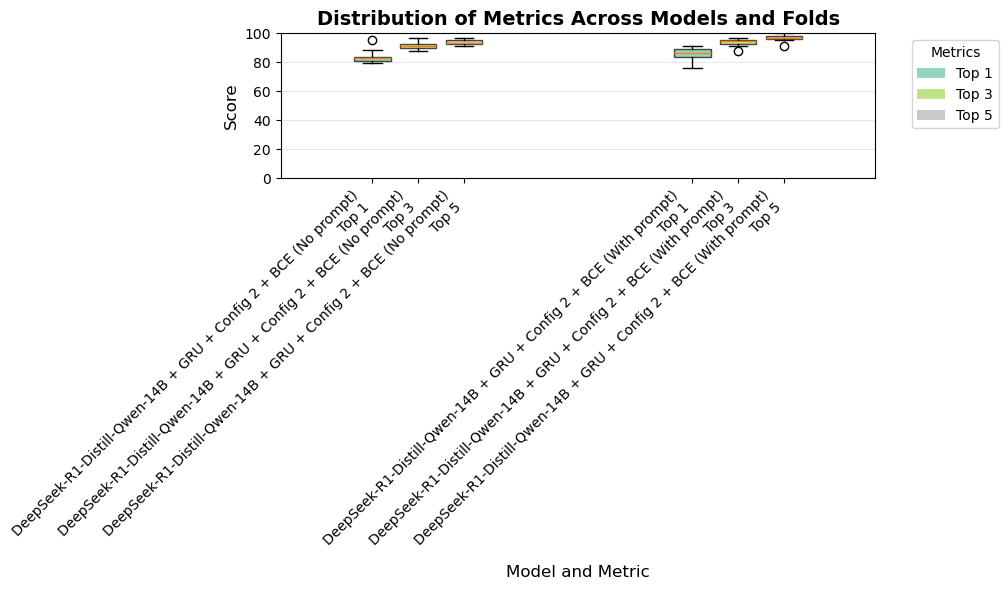

In [125]:
Helper.plot_grouped_boxplots({'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (No prompt)': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_1'],
                                               'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_3'],
                                               'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_5']},
                      'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2 + BCE (With prompt)': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_1'],
                                      'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_3'],
                                      'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_5']}},
                    fig_width=1000, fig_height=600, title="Distribution of Metrics Across Models and Folds", x_label="Model and Metric", y_label="Score", range_min=0.0, range_max=100.00)

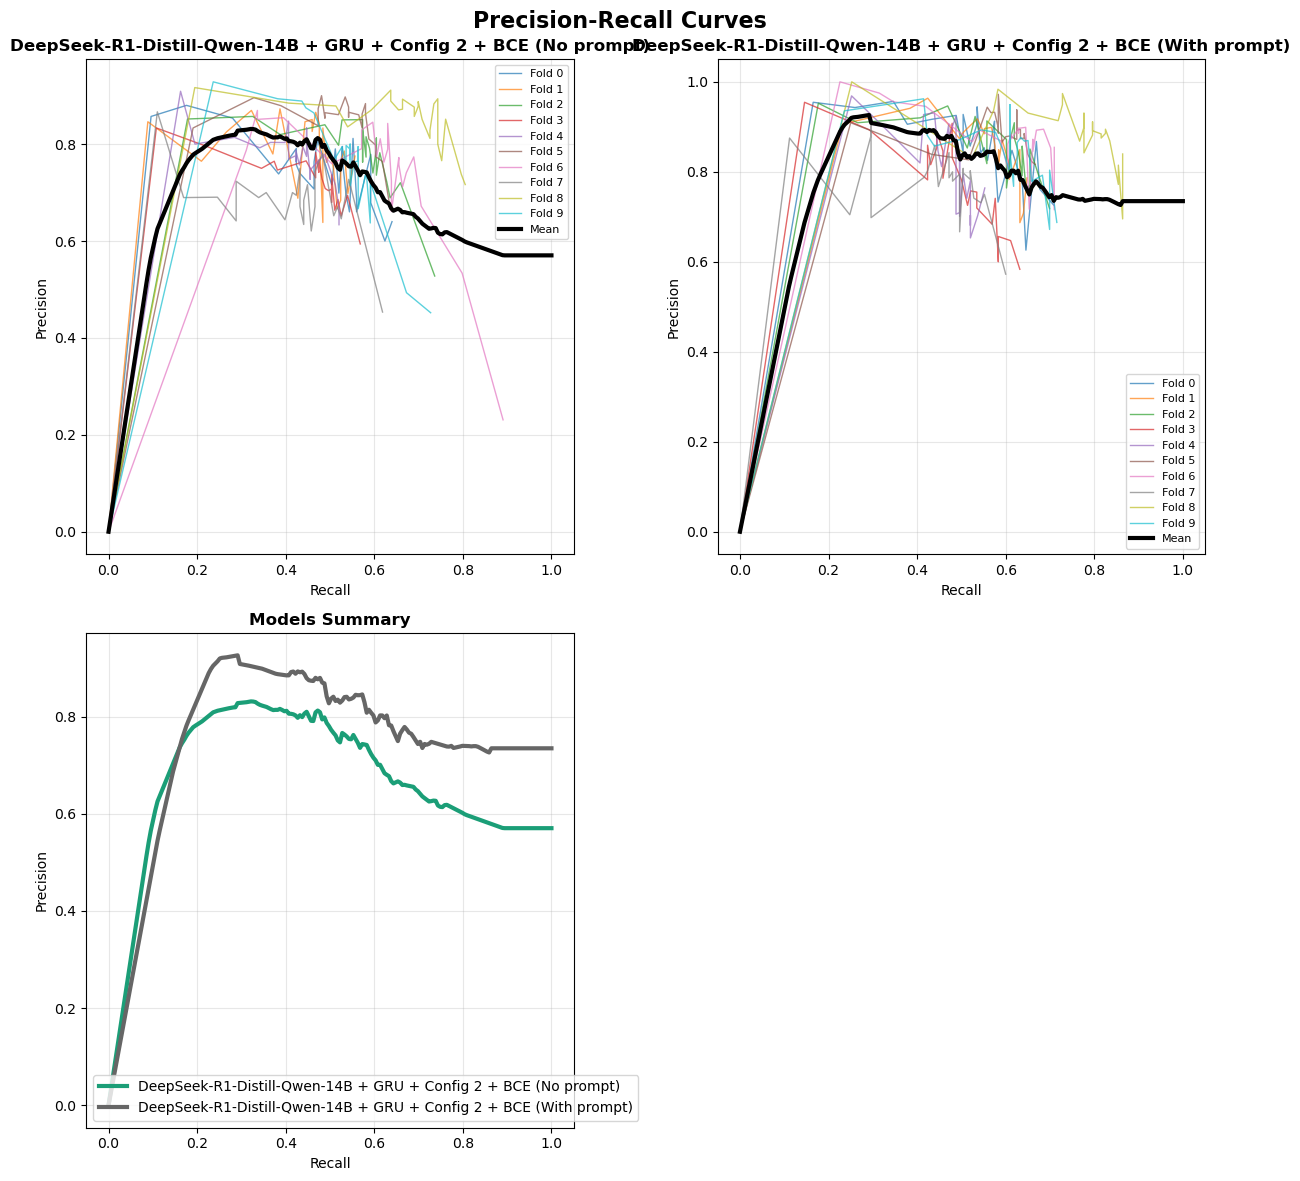

In [127]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = [
    'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE',
    'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE'
]
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2].replace("_", "-")
    if 'linear' in experiment.split('/')[3]:
        model_name += " + Linear"
    if 'gru' in experiment.split('/')[3]:
        model_name += " + GRU"
    if '1' in experiment.split('/')[3].split('_')[6]:
        model_name += " + Confi 1"
    if '2' in experiment.split('/')[3].split('_')[6]:
        model_name += " + Config 2"
    if 'BCE' in experiment.split('/')[3]:
        model_name += " + BCE"
    if 'CC' in experiment.split('/')[3]:
        model_name += " + Custom Loss"
    if 'exp11' in experiment.split('/')[3]:
        model_name += " (No prompt)"
    if 'exp10' in experiment.split('/')[3]:
        model_name += " (With prompt)"
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=1200
    )

## Test using different prompts from trained prompt to for the impact for the improved model trained on Solidity localization dataset

## Summary

In [130]:
experiments = ['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE',
               'solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']


Friedman Test: statistic = 30.0000, p = 0.0000

Average Ranks:
Qwen-QwQ-32B + GRU - Config 1: 2.900
DeepSeek-R1-Distill-Llama-8B + GRU - Config 1: 3.400
DeepSeek-R1-Distill-Qwen-14B + GRU - Config 1: 2.800
CodeGen-16B + GRU  - Config 1: 5.900
DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2: 1.700
DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2 (No prompt): 4.300

Nemenyi Post-hoc Test (p-values):
                                                    Qwen-QwQ-32B + GRU - Config 1  \
Qwen-QwQ-32B + GRU - Config 1                                            1.000000   
DeepSeek-R1-Distill-Llama-8B + GRU - Config 1                            0.991226   
DeepSeek-R1-Distill-Qwen-14B + GRU - Config 1                            0.999997   
CodeGen-16B + GRU  - Config 1                                            0.004537   
DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2                            0.706032   
DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2 (...                       0.549547   

       

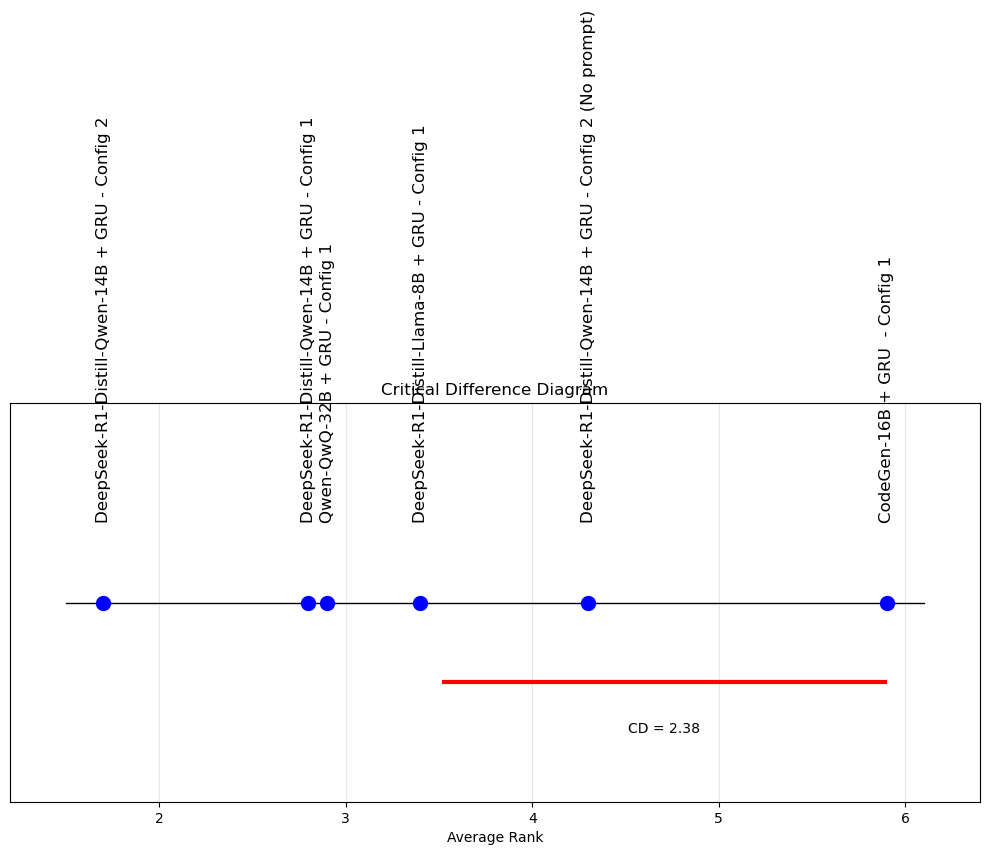

In [132]:
Helper.friedman_and_nemenyi({'Qwen-QwQ-32B + GRU - Config 1': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU - Config 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU - Config 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + GRU  - Config 1': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2 (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['f1_score']},
                            fig_width=1000, fig_height=800, name="localization_cd")

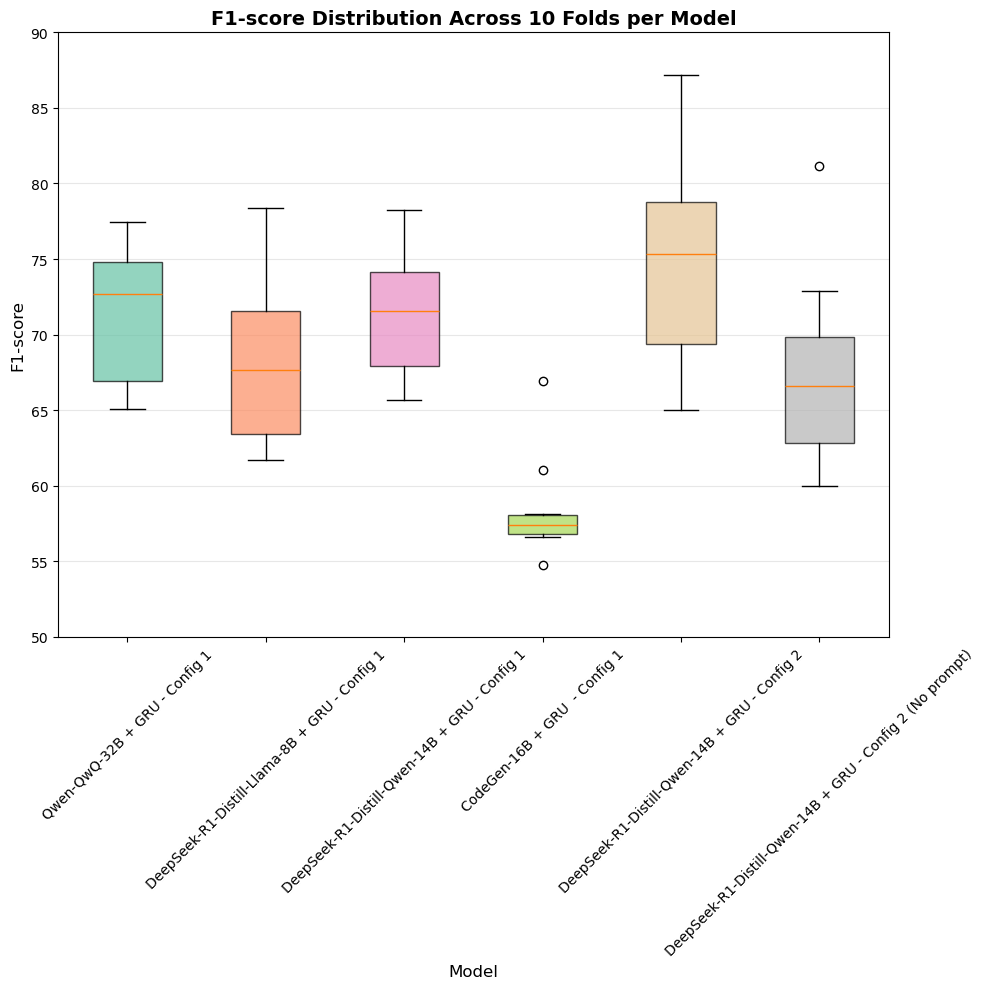

In [134]:
Helper.plot_boxplots({'Qwen-QwQ-32B + GRU - Config 1': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Llama-8B + GRU - Config 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU - Config 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['f1_score'],
                             'CodeGen-16B + GRU  - Config 1': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['f1_score'],
                             'DeepSeek-R1-Distill-Qwen-14B + GRU - Config 2 (No prompt)': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['f1_score']},
                    fig_width=1000, fig_height=1000, title="F1-score Distribution Across 10 Folds per Model", x_label="Model", y_label="F1-score", range_min=50.00, range_max=90.00)

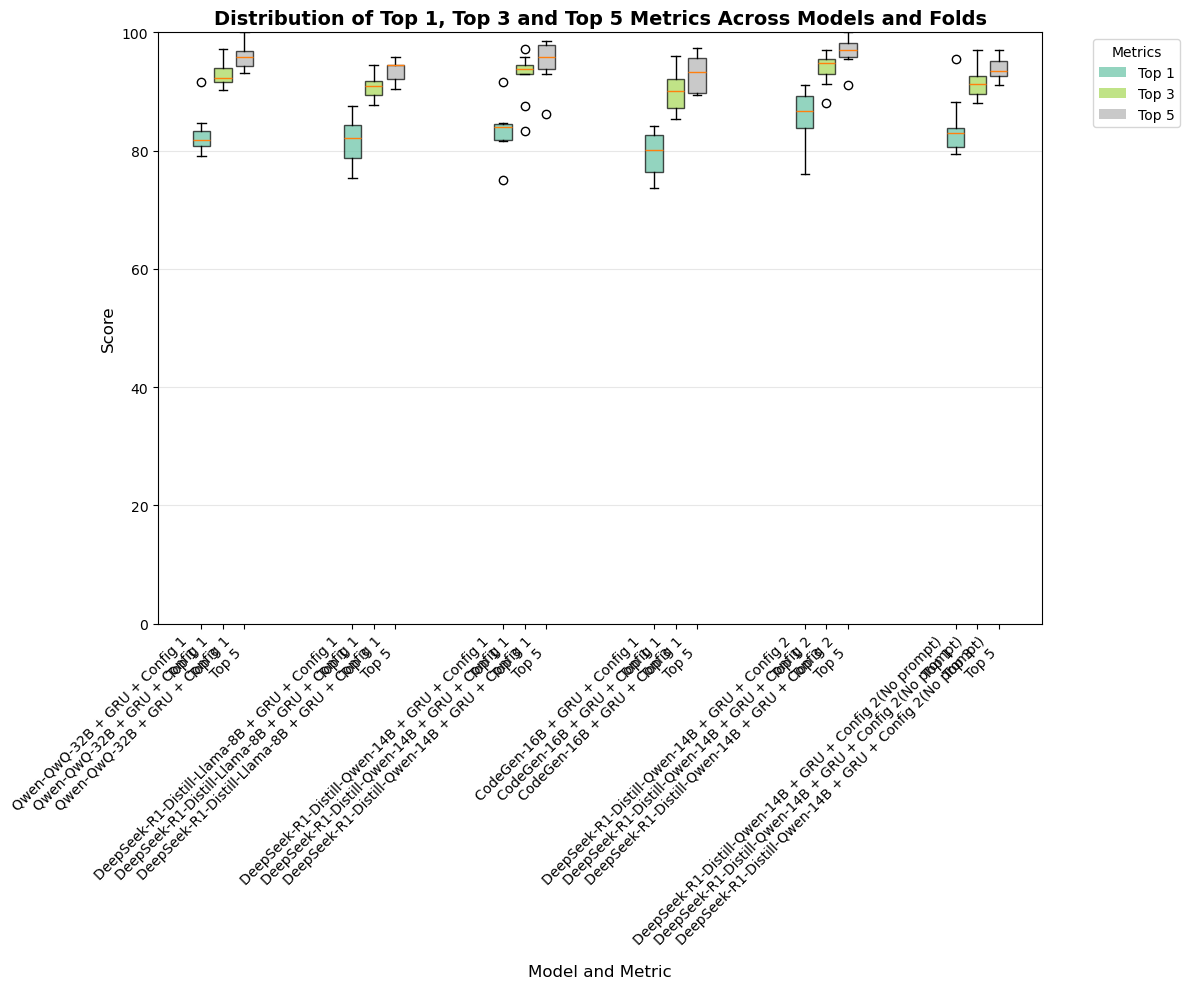

In [136]:
Helper.plot_grouped_boxplots({'Qwen-QwQ-32B + GRU + Config 1': {'Top 1': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_1'],
                                               'Top 3': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_3'],
                                               'Top 5': experiment_results['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE']['top_5']},
                      'DeepSeek-R1-Distill-Llama-8B + GRU + Config 1': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_1'],
                                     'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_3'],
                                     'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE']['top_5']},
                      'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 1': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_1'],
                                      'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_3'],
                                      'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE']['top_5']},
                             'CodeGen-16B + GRU + Config 1': {'Top 1': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_1'],
                                               'Top 3': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_3'],
                                               'Top 5': experiment_results['solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE']['top_5']},
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_1'],
                                      'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_3'],
                                      'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE']['top_5']},
                             'DeepSeek-R1-Distill-Qwen-14B + GRU + Config 2(No prompt)': {'Top 1': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_1'],
                                      'Top 3': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_3'],
                                      'Top 5': experiment_results['solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']['top_5']}},
                    fig_width=1200, fig_height=1000, title="Distribution of Top 1, Top 3 and Top 5 Metrics Across Models and Folds", x_label="Model and Metric", y_label="Score", range_min=0.0, range_max=100.00)

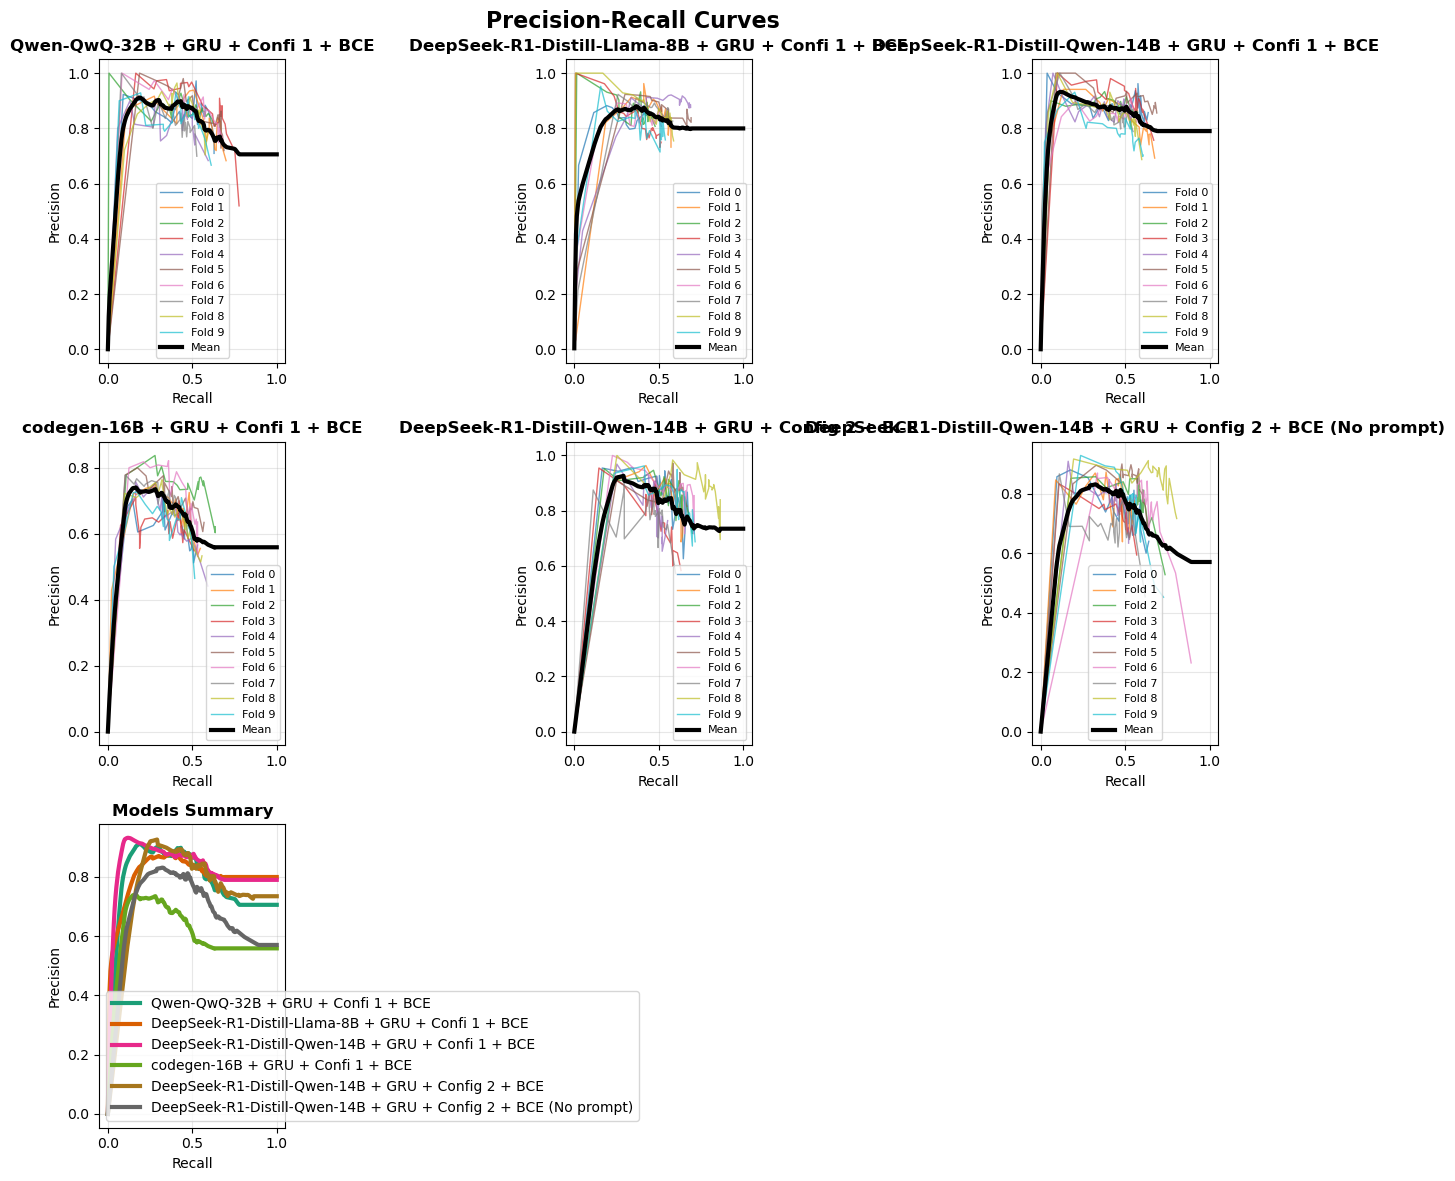

In [138]:
# pr_data = { model_name: { fold_idx: {'precision': array, 'recall': array}, ... }, ... }
import pandas as pd
min_steps = 10000000
sub_experiments = ['solidity/v2/Qwen_QwQ_32B/exp6_solidity_v2_17_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Llama_8B/exp7_solidity_v2_18_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp8_solidity_v2_19_gru_1024_1_BCE',
               'solidity/v3/codegen_16B/exp9_solidity_v3_3_gru_1024_1_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp10_solidity_v2_19_gru_1024_2_BCE',
               'solidity/v2/DeepSeek_R1_Distill_Qwen_14B/exp11_solidity_v2_19_gru_1024_2_BCE']
for experiment in sub_experiments:
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        min_steps_temp = min(len(val_precision), len(val_recall))
        min_steps = min(min_steps, min_steps_temp)

pr_data = dict()
for experiment in sub_experiments:
    model_name = experiment.split('/')[2].replace("_", "-")
    if 'linear' in experiment.split('/')[3]:
        model_name += " + Linear"
    if 'gru' in experiment.split('/')[3]:
        model_name += " + GRU"
    if '1' in experiment.split('/')[3].split('_')[6]:
        model_name += " + Confi 1"
    if '2' in experiment.split('/')[3].split('_')[6]:
        model_name += " + Config 2"
    if 'BCE' in experiment.split('/')[3]:
        model_name += " + BCE"
    if 'CC' in experiment.split('/')[3]:
        model_name += " + Custom Loss"
    if 'exp11' in experiment.split('/')[3]:
        model_name += " (No prompt)"
    # if 'exp10' in experiment.split('/')[3]:
    #     model_name += " (With prompt)"
    pr_data[model_name] = dict()
    for k in range(10):
        val_precision_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/precision_val.csv"
        val_recall_file = f"{outputs_csv_folder}/{experiment}/fold_{k}/recall_val.csv"
        val_precision_df = pd.read_csv(val_precision_file)
        val_recall_df = pd.read_csv(val_recall_file)
        val_precision = val_precision_df['value'].tolist()
        val_recall = val_recall_df['value'].tolist()
        pr_data[model_name][k] = {'precision': val_precision[:min_steps], 'recall': val_recall[:min_steps]}

#print(pr_data)

Helper.plot_precision_recall_curves(
        pr_data,
        summary_method='interpolation',
        template='plotly_white',
        fig_width=1200,
        fig_height=1200
    )